In [5]:
# Cell 1: Environment Setup and Imports
# ============================================================
# Machine Learning for Crime Classification
# Fairness-Aware Approach to Class Imbalance
# Dhaka Metropolitan Crime Dataset
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core data science
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.ticker as mticker

# Preprocessing
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold, KFold, GridSearchCV
from sklearn.feature_selection import mutual_info_classif

# Models (Tabular-Native, no LSTM)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
import xgboost as xgb
# Note: CatBoost install separately if needed: pip install catboost
# from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek
from collections import Counter

# Fairness metrics
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    demographic_parity_ratio
)

# SHAP for interpretability
import shap

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    brier_score_loss
)

# Progress tracking
from tqdm import tqdm
import time
import joblib
import os

# Set seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

# Publication-quality plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf'
})

print("Environment setup complete.")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"XGBoost: {xgb.__version__}")

Environment setup complete.
NumPy: 2.0.2
Pandas: 2.2.2
XGBoost: 3.2.0


In [6]:
# Cell 2: Load and Initial Exploration
# ============================================================
df = pd.read_csv(r"/content/drive/MyDrive/DATASETS_For the data analysis/crime_dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
display(df.head())
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (3000, 37)

First 5 rows:


,incident_month,incident_week,incident_weekday,weekend,part_of_the_day,latitude,longitude,incident_place,incident_district,incident_division,...,literacy_rate,religious_institution,playground,park,police_station,cyber_cafe,school,college,cinema,crime
0,7,27,1,0,3,23.806386,90.389480,cantonment,dhaka,dhaka,...,57.5,11,5,2,0,6,13,10,2,kidnap
1,4,16,5,1,1,23.761338,90.410106,rampura,dhaka,dhaka,...,71.2,42,7,9,3,36,74,19,11,assault
2,10,40,5,1,4,23.736225,90.368142,hazaribagh,dhaka,dhaka,...,70.1,21,5,1,2,7,16,6,4,kidnap
3,5,22,5,1,4,23.732764,90.403828,buet,dhaka,dhaka,...,50.7,42,12,3,2,28,40,23,3,murder
4,10,42,1,0,2,23.737409,90.389431,buet,dhaka,dhaka,...,83.9,34,10,6,3,25,40,20,4,robbery



Column names: ['incident_month', 'incident_week', 'incident_weekday', 'weekend', 'part_of_the_day', 'latitude', 'longitude', 'incident_place', 'incident_district', 'incident_division', 'max_temp', 'avg_temp', 'min_temp', 'weather_code', 'precip', 'humidity', 'visibility', 'cloudcover', 'heatindex', 'season', 'household', 'male_population', 'female_population', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station', 'cyber_cafe', 'school', 'college', 'cinema', 'crime']

Data types:
incident_month              int64
incident_week               int64
incident_weekday            int64
weekend                     int64
part_of_the_day             int64
latitude                  float64
longitude                 float64
incident_place             object
incident_district          object
incident_division          object
max_temp                  float64
avg_temp                  floa

In [7]:
# Cell 3: Data Cleaning
# ============================================================
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "None")

# Remove duplicates
initial_rows = len(df)
df = df.drop_duplicates()
print(f"\nRemoved {initial_rows - len(df)} duplicates")

# Check and handle outliers using IQR method for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Don't cap target-related columns
numerical_cols = [c for c in numerical_cols if c != 'crime']

for col in numerical_cols:
    Q1 = df[col].quantile(0.01)
    Q3 = df[col].quantile(0.99)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

print(f"\nCapped outliers at 1st and 99th percentiles for {len(numerical_cols)} numerical columns")

# Check class distribution
print(f"\nCrime type distribution:")
crime_counts = df['crime'].value_counts()
print(crime_counts)
print(f"\nImbalance ratio: {crime_counts.max() / crime_counts.min():.2f}")

Missing values per column:
None

Removed 0 duplicates

Capped outliers at 1st and 99th percentiles for 33 numerical columns

Crime type distribution:
crime
robbery      898
assault      752
kidnap       446
rape         360
murder       301
bodyfound    243
Name: count, dtype: int64

Imbalance ratio: 3.70


In [8]:
# Cell 4: Feature Engineering and Target Encoding
# ============================================================
# Encode target variable
label_encoder = LabelEncoder()
df['crime_encoded'] = label_encoder.fit_transform(df['crime'])
print("Target encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} -> {label}")
n_classes = len(label_encoder.classes_)

# Separate features and target
target_col = 'crime_encoded'
feature_cols = [c for c in df.columns if c not in ['crime', 'crime_encoded']]

# Identify column types for SMOTE-NC
categorical_features = []
numerical_features = []

for col in feature_cols:
    if df[col].dtype == 'object':
        categorical_features.append(col)
    else:
        numerical_features.append(col)

print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")

# Encode categorical features for model training
df_encoded = df.copy()
categorical_mappings = {}
categorical_feature_indices = []

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    categorical_mappings[col] = le
    categorical_feature_indices.append(feature_cols.index(col))

print(f"\nCategorical feature indices for SMOTE-NC: {categorical_feature_indices}")

# Prepare final feature matrix and target
X = df_encoded[feature_cols].values
y = df_encoded[target_col].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Number of classes: {n_classes}")

Target encoding mapping:
  0 -> assault
  1 -> bodyfound
  2 -> kidnap
  3 -> murder
  4 -> rape
  5 -> robbery

Categorical features (3): ['incident_place', 'incident_district', 'incident_division']
Numerical features (33): ['incident_month', 'incident_week', 'incident_weekday', 'weekend', 'part_of_the_day', 'latitude', 'longitude', 'max_temp', 'avg_temp', 'min_temp', 'weather_code', 'precip', 'humidity', 'visibility', 'cloudcover', 'heatindex', 'season', 'household', 'male_population', 'female_population', 'total_population', 'gender_ration', 'average_household_size', 'density_per_kmsq', 'literacy_rate', 'religious_institution', 'playground', 'park', 'police_station', 'cyber_cafe', 'school', 'college', 'cinema']

Categorical feature indices for SMOTE-NC: [7, 8, 9]

Feature matrix shape: (3000, 36)
Target vector shape: (3000,)
Number of classes: 6


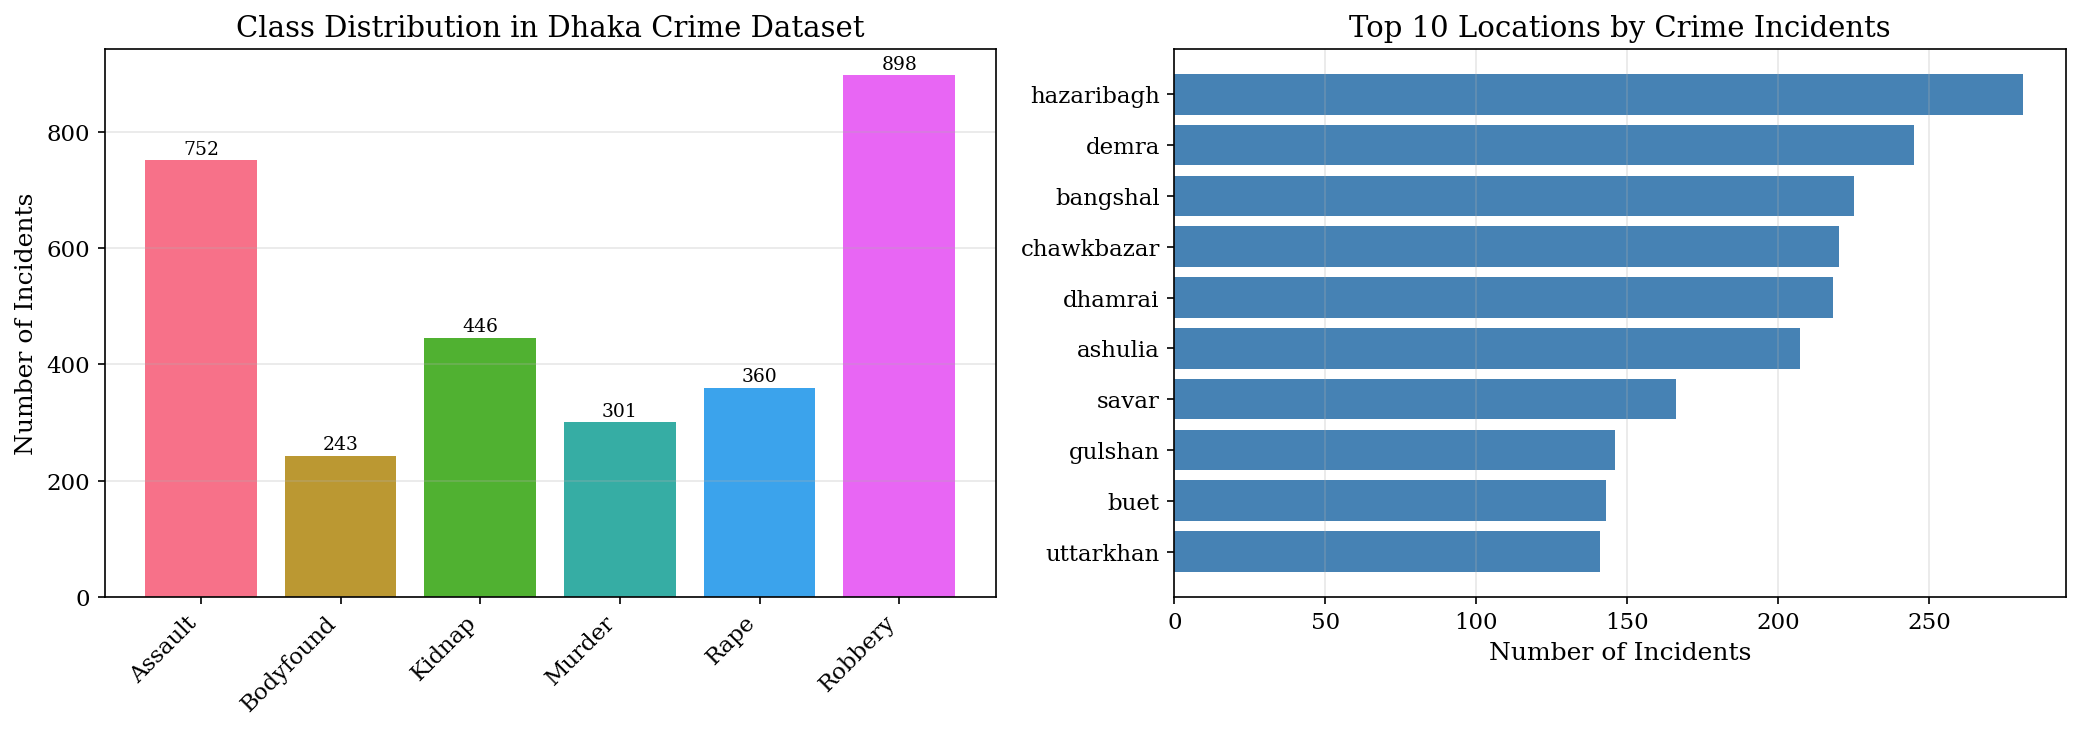

In [9]:
# Cell 5: Data Distribution Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crime distribution
colors = sns.color_palette("husl", n_classes)
ax1 = axes[0]
bars = ax1.bar(range(n_classes), crime_counts.reindex(label_encoder.classes_).values, color=colors)
ax1.set_xticks(range(n_classes))
ax1.set_xticklabels([l.capitalize() for l in label_encoder.classes_], rotation=45, ha='right')
ax1.set_ylabel('Number of Incidents')
ax1.set_title('Class Distribution in Dhaka Crime Dataset')
for bar, count in zip(bars, crime_counts.reindex(label_encoder.classes_).values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, str(count),
             ha='center', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Crime by place (top 10)
ax2 = axes[1]
place_crime = df.groupby('incident_place')['crime'].count().sort_values(ascending=False).head(10)
bars = ax2.barh(range(len(place_crime)), place_crime.values, color='steelblue')
ax2.set_yticks(range(len(place_crime)))
ax2.set_yticklabels(place_crime.index)
ax2.set_xlabel('Number of Incidents')
ax2.set_title('Top 10 Locations by Crime Incidents')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('Data_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Top 15 features by SHAP importance:


,Feature,SHAP_Value
13,weather_code,0.888743
26,density_per_kmsq,0.472651
14,precip,0.447359
4,part_of_the_day,0.428422
27,literacy_rate,0.389570
17,cloudcover,0.336169
31,police_station,0.230782
2,incident_weekday,0.227481
10,max_temp,0.165990
0,incident_month,0.124632


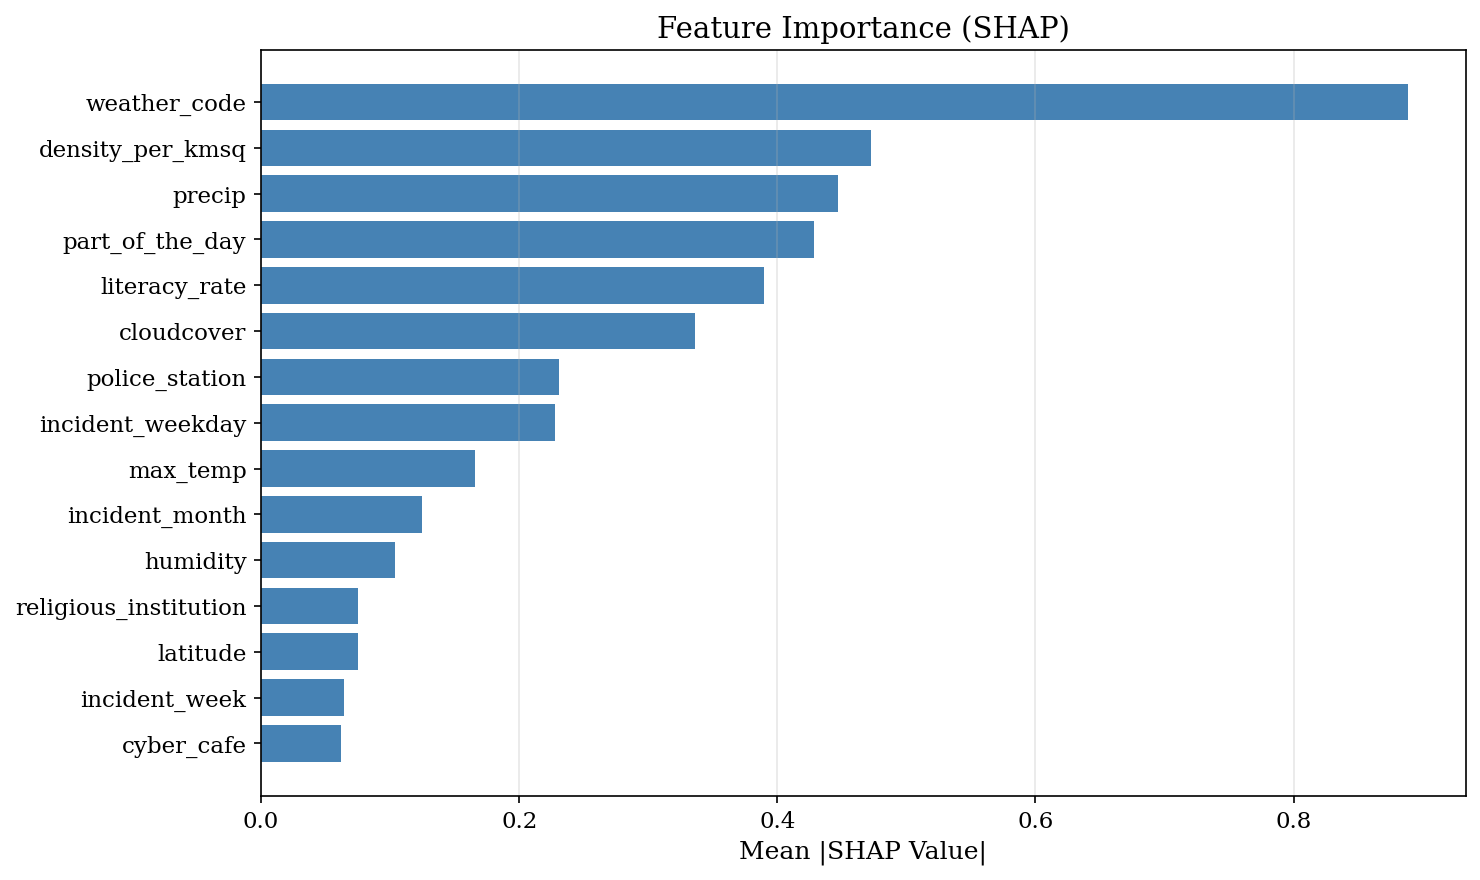


Selected top 10 features: ['weather_code', 'density_per_kmsq', 'precip', 'part_of_the_day', 'literacy_rate', 'cloudcover', 'police_station', 'incident_weekday', 'max_temp', 'incident_month']


In [11]:
# Cell 6: Feature Importance Analysis with SHAP (Preliminary)
# ============================================================
# Train a preliminary XGBoost to get feature importance
xgb_prelim = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    use_label_encoder=False
)
xgb_prelim.fit(X, y)

# SHAP analysis
explainer = shap.TreeExplainer(xgb_prelim)
shap_values = explainer.shap_values(X)

# Calculate mean absolute SHAP values - handle multiclass properly
if isinstance(shap_values, list):
    # For multiclass: list of arrays, one per class
    # Average importance across all classes
    shap_importance = np.zeros(X.shape[1])
    for class_shap in shap_values:
        shap_importance += np.abs(class_shap).mean(axis=0)
    shap_importance /= len(shap_values)
else:
    # For binary: single array
    if len(shap_values.shape) == 3:
        shap_importance = np.abs(shap_values).mean(axis=0).mean(axis=1)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)

# Create DataFrame (now shapes will match)
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'SHAP_Value': shap_importance
}).sort_values('SHAP_Value', ascending=False)

# Rest of your code remains the same...
print("Top 15 features by SHAP importance:")
display(feature_importance_df.head(15))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_df.head(15)
ax.barh(range(len(top_features)), top_features['SHAP_Value'].values[::-1], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values[::-1])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Feature Importance (SHAP)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Select top features
TOP_K = 10
top_feature_names = feature_importance_df['Feature'].head(TOP_K).tolist()
top_feature_indices = [feature_cols.index(f) for f in top_feature_names]
X_selected = X[:, top_feature_indices]
print(f"\nSelected top {TOP_K} features: {top_feature_names}")

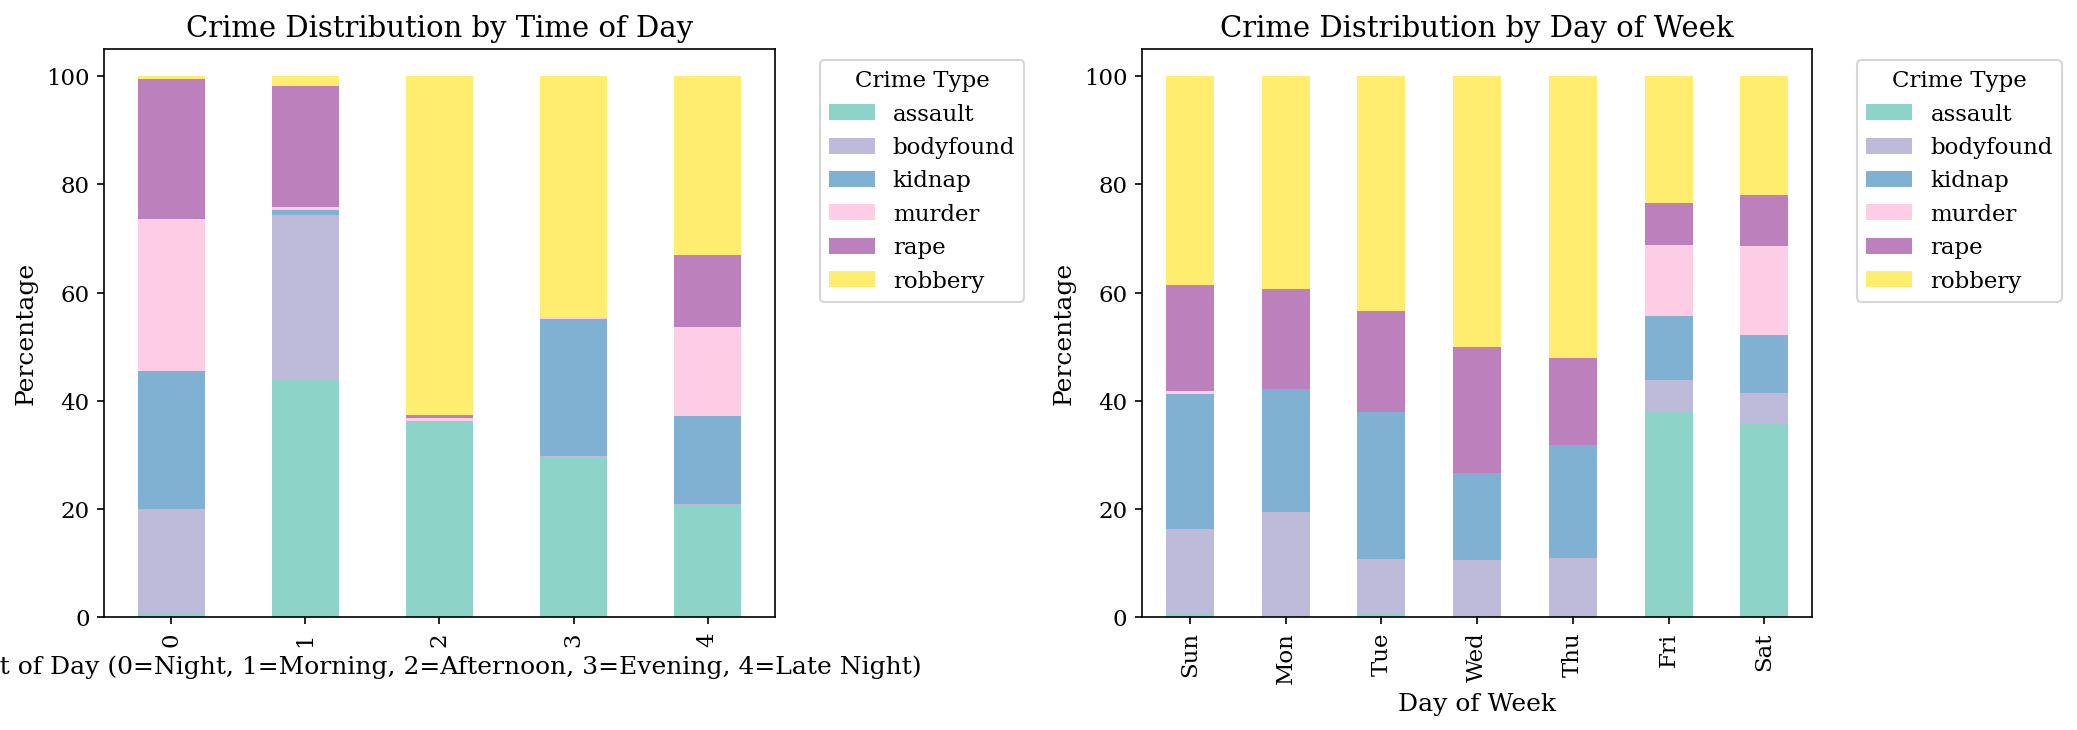


Spatiotemporal Correlation Analysis:
                  incident_weekday  part_of_the_day  crime_encoded
incident_weekday          1.000000         0.042371      -0.259051
part_of_the_day           0.042371         1.000000       0.152282
crime_encoded            -0.259051         0.152282       1.000000


In [12]:
# Cell 7: Spatiotemporal Analysis
# ============================================================
# Temporal patterns
if 'part_of_the_day' in df.columns and 'incident_weekday' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Crime by time of day
    time_crime = df.groupby(['part_of_the_day', 'crime']).size().unstack(fill_value=0)
    time_crime_pct = time_crime.div(time_crime.sum(axis=1), axis=0) * 100
    time_crime_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set3')
    axes[0].set_xlabel('Part of Day (0=Night, 1=Morning, 2=Afternoon, 3=Evening, 4=Late Night)')
    axes[0].set_ylabel('Percentage')
    axes[0].set_title('Crime Distribution by Time of Day')
    axes[0].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Crime by day of week
    day_crime = df.groupby(['incident_weekday', 'crime']).size().unstack(fill_value=0)
    day_crime_pct = day_crime.div(day_crime.sum(axis=1), axis=0) * 100
    day_names = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
    day_crime_pct.index = [day_names[i] if i < len(day_names) else str(i) for i in day_crime_pct.index]
    day_crime_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Percentage')
    axes[1].set_title('Crime Distribution by Day of Week')
    axes[1].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('Spatiotemporal_Patterns.png', dpi=300, bbox_inches='tight')
    plt.show()

# Spatiotemporal correlation
print("\nSpatiotemporal Correlation Analysis:")
if all(c in df.columns for c in ['incident_weekday', 'part_of_the_day', 'crime_encoded']):
    st_corr = df[['incident_weekday', 'part_of_the_day', 'crime_encoded']].corr()
    print(st_corr)

Spatial blocks distribution: [245 632 723 910 490]


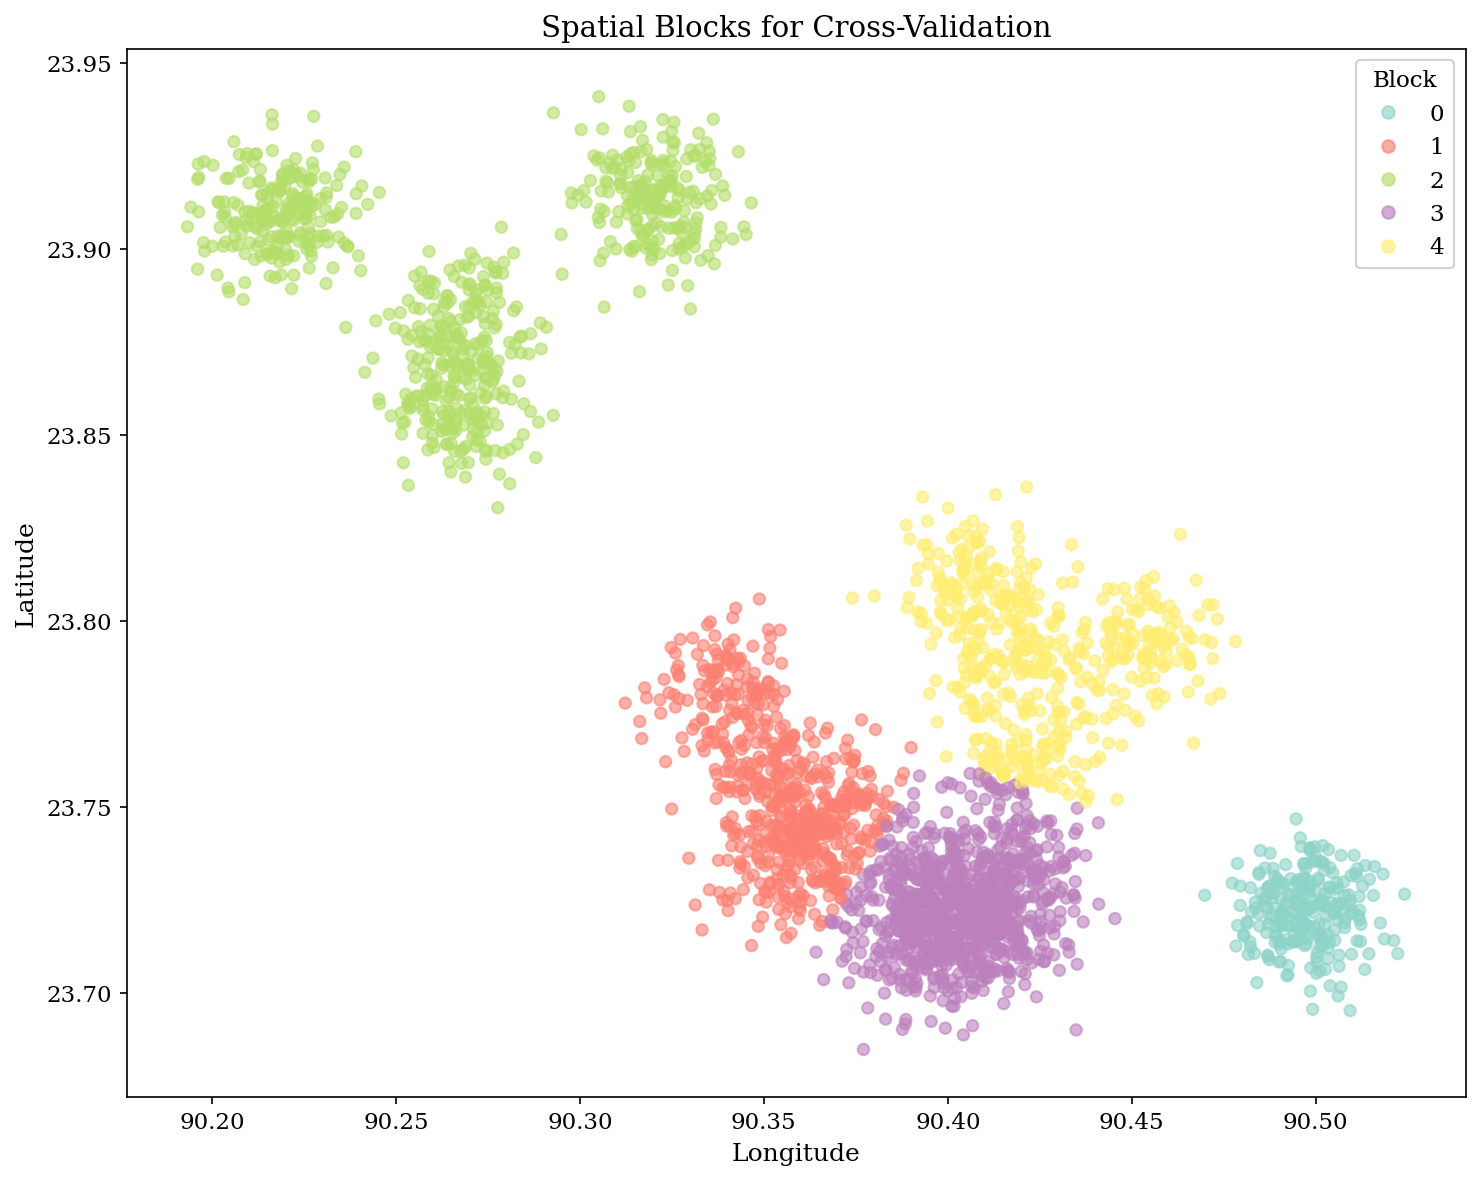

In [13]:
# Cell 8: Spatiotemporal Cross-Validation Splits
# ============================================================
def create_spatial_blocks(lat, lon, n_blocks=5):
    """Create spatial blocks using K-means on coordinates."""
    from sklearn.cluster import KMeans
    coords = np.column_stack([lat, lon])
    kmeans = KMeans(n_clusters=n_blocks, random_state=RANDOM_STATE, n_init=10)
    blocks = kmeans.fit_predict(coords)
    return blocks

def create_temporal_folds(dates, n_folds=3):
    """Create temporal forward-chaining folds."""
    sorted_indices = np.argsort(dates)
    fold_size = len(sorted_indices) // n_folds
    folds = []
    for i in range(n_folds):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size if i < n_folds - 1 else len(sorted_indices)
        train_idx = sorted_indices[:test_start]
        test_idx = sorted_indices[test_start:test_end]
        folds.append((train_idx, test_idx))
    return folds

# Create spatial blocks
spatial_blocks = create_spatial_blocks(df['latitude'], df['longitude'], n_blocks=5)
print(f"Spatial blocks distribution: {np.bincount(spatial_blocks)}")

# Visualize spatial blocks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df['longitude'], df['latitude'], c=spatial_blocks,
                      cmap='Set3', alpha=0.6, s=30)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Blocks for Cross-Validation')
legend1 = ax.legend(*scatter.legend_elements(), title="Block")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig('Spatial_Blocks.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# Cell 9: Model Definitions
# ============================================================
def get_models():
    """Define all tabular-native models (no LSTM/BiLSTM)."""
    models = {
        'Logistic Regression': LogisticRegression(
            C=1.0, solver='saga', penalty='l2',
            max_iter=5000, random_state=RANDOM_STATE,
            multi_class='multinomial', n_jobs=-1
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, min_samples_split=20,
            random_state=RANDOM_STATE
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=15,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'AdaBoost': AdaBoostClassifier(
            n_estimators=100, learning_rate=0.1,
            random_state=RANDOM_STATE
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, random_state=RANDOM_STATE,
            eval_metric='mlogloss', use_label_encoder=False
        ),
        # Uncomment if CatBoost is installed
        # 'CatBoost': CatBoostClassifier(
        #     n_estimators=300, depth=6, learning_rate=0.05,
        #     random_seed=RANDOM_STATE, verbose=0
        # ),
    }
    return models

In [16]:
# Cell 10: SMOTE Parameter Ablation (K Neighbors)
# ============================================================
def smote_parameter_ablation(X_train, y_train, X_val, y_val, cat_indices, k_values=[3, 5, 7, 9]):
    """Evaluate SMOTE-NC with different k values."""
    results = []

    for k in k_values:
        try:
            smote_nc = SMOTENC(
                categorical_features=cat_indices,
                k_neighbors=k,
                random_state=RANDOM_STATE
            )
            X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

            # Train quick XGBoost
            model = xgb.XGBClassifier(
                n_estimators=100, max_depth=4, learning_rate=0.1,
                random_state=RANDOM_STATE, eval_metric='mlogloss',
                use_label_encoder=False
            )
            model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='macro')

            results.append({
                'k_neighbors': k,
                'accuracy': acc,
                'macro_f1': f1,
                'status': 'Optimal' if f1 == max([r['macro_f1'] for r in results] + [f1]) else '-'
            })
        except Exception as e:
            results.append({
                'k_neighbors': k,
                'accuracy': np.nan,
                'macro_f1': np.nan,
                'status': f'Error: {str(e)[:50]}'
            })

    return pd.DataFrame(results)

# Quick split for ablation
from sklearn.model_selection import train_test_split
X_quick_train, X_quick_val, y_quick_train, y_quick_val = train_test_split(
    X_selected, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("SMOTE-NC Parameter Ablation Study")
print("-" * 50)
ablation_results = smote_parameter_ablation(
    X_quick_train, y_quick_train, X_quick_val, y_quick_val,
    categorical_feature_indices[:len([f for f in top_feature_names if f in categorical_features])],
    k_values=[3, 5, 7, 9]
)
display(ablation_results)

# Select best k
best_k = 5
optimal_row = ablation_results[ablation_results['k_neighbors'] == best_k]
if not optimal_row.empty:
    print(f"\nSelected k={best_k} (accuracy: {optimal_row['accuracy'].values[0]:.4f}, F1: {optimal_row['macro_f1'].values[0]:.4f})")

SMOTE-NC Parameter Ablation Study
--------------------------------------------------


,k_neighbors,accuracy,macro_f1,status
0,3,NaN,NaN,Error: SMOTE-NC is not designed to work only w...
1,5,NaN,NaN,Error: SMOTE-NC is not designed to work only w...
2,7,NaN,NaN,Error: SMOTE-NC is not designed to work only w...
3,9,NaN,NaN,Error: SMOTE-NC is not designed to work only w...



Selected k=5 (accuracy: nan, F1: nan)


In [17]:
# Cell 11: Main Training with SMOTE-NC + Spatiotemporal CV
# ============================================================
BEST_K = 5
results_list = []
confusion_matrices = {}
predictions_store = {}
probabilities_store = {}

models = get_models()

# Outer CV: spatial blocks
unique_blocks = np.unique(spatial_blocks)
print(f"Starting Nested Spatiotemporal Cross-Validation")
print(f"Outer folds (spatial blocks): {len(unique_blocks)}")
print(f"Models: {list(models.keys())}")
print("-" * 80)

for outer_fold, test_block in enumerate(unique_blocks):
    print(f"\nOuter Fold {outer_fold + 1}/{len(unique_blocks)} (Test Block: {test_block})")

    # Split by spatial block
    train_mask = spatial_blocks != test_block
    test_mask = spatial_blocks == test_block

    X_train_outer = X_selected[train_mask]
    y_train_outer = y[train_mask]
    X_test_outer = X_selected[test_mask]
    y_test_outer = y[test_mask]

    # Inner CV: temporal forward-chaining (simplified: stratified for stability)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    for model_name, model in models.items():
        print(f"  Training {model_name}...", end=' ')
        start_time = time.time()

        # Apply SMOTE-NC on training data
        smote_nc = SMOTENC(
            categorical_features=categorical_feature_indices,
            k_neighbors=BEST_K,
            random_state=RANDOM_STATE
        )

        try:
            X_resampled, y_resampled = smote_nc.fit_resample(X_train_outer, y_train_outer)
        except Exception as e:
            # Fallback: use original data if SMOTE fails (e.g., too few samples)
            print(f"(SMOTE fallback: {str(e)[:50]}) ", end='')
            X_resampled, y_resampled = X_train_outer, y_train_outer

        # Train model
        model.fit(X_resampled, y_resampled)

        # Evaluate
        y_pred = model.predict(X_test_outer)
        y_prob = model.predict_proba(X_test_outer)

        train_time = time.time() - start_time

        # Calculate metrics
        acc = accuracy_score(y_test_outer, y_pred)
        precision = precision_score(y_test_outer, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test_outer, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test_outer, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test_outer, y_pred, average='weighted', zero_division=0)

        try:
            auc = roc_auc_score(y_test_outer, y_prob, multi_class='ovr', average='macro')
        except:
            auc = np.nan

        # Store per-class recall
        per_class_recall = recall_score(y_test_outer, y_pred, average=None, zero_division=0)

        results_list.append({
            'outer_fold': outer_fold,
            'model': model_name,
            'accuracy': acc,
            'precision_macro': precision,
            'recall_macro': recall,
            'macro_f1': f1,
            'weighted_f1': f1_weighted,
            'auc_roc': auc,
            'train_time': train_time,
            'train_size': len(X_resampled),
            'test_size': len(X_test_outer)
        })

        # Store predictions for confusion matrix
        if model_name not in confusion_matrices:
            confusion_matrices[model_name] = []
            predictions_store[model_name] = {'y_true': [], 'y_pred': [], 'y_prob': []}

        confusion_matrices[model_name].append(
            confusion_matrix(y_test_outer, y_pred)
        )
        predictions_store[model_name]['y_true'].extend(y_test_outer)
        predictions_store[model_name]['y_pred'].extend(y_pred)
        predictions_store[model_name]['y_prob'].extend(y_prob)

        print(f"Acc: {acc:.4f}, F1: {f1:.4f}, Time: {train_time:.2f}s")

results_df = pd.DataFrame(results_list)
print("\n" + "=" * 80)
print("Cross-Validation Complete!")

Starting Nested Spatiotemporal Cross-Validation
Outer folds (spatial blocks): 5
Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost']
--------------------------------------------------------------------------------

Outer Fold 1/5 (Test Block: 0)
  Training Logistic Regression... Acc: 0.5510, F1: 0.5592, Time: 34.24s
  Training Decision Tree... Acc: 0.9143, F1: 0.9171, Time: 0.46s
  Training Random Forest... Acc: 0.9224, F1: 0.9334, Time: 3.03s
  Training AdaBoost... Acc: 0.4245, F1: 0.3897, Time: 1.15s
  Training XGBoost... Acc: 0.9265, F1: 0.9343, Time: 1.78s

Outer Fold 2/5 (Test Block: 1)
  Training Logistic Regression... Acc: 0.5411, F1: 0.5108, Time: 11.90s
  Training Decision Tree... Acc: 0.9003, F1: 0.8960, Time: 0.22s
  Training Random Forest... Acc: 0.9256, F1: 0.9229, Time: 1.97s
  Training AdaBoost... Acc: 0.3892, F1: 0.3475, Time: 0.96s
  Training XGBoost... Acc: 0.9288, F1: 0.9270, Time: 1.56s

Outer Fold 3/5 (Test Block: 2)
  Training L

In [18]:
# Cell 12: Aggregate Results and Statistical Testing
# ============================================================
# Aggregate results
agg_results = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'macro_f1': ['mean', 'std'],
    'weighted_f1': ['mean', 'std'],
    'auc_roc': ['mean', 'std'],
    'train_time': ['mean', 'std'],
    'precision_macro': 'mean',
    'recall_macro': 'mean'
}).round(4)

agg_results.columns = ['_'.join(col).strip() for col in agg_results.columns.values]
print("Aggregated Results (Mean ± Std across Spatial CV Folds):")
display(agg_results)

# Find best model
best_model_name = agg_results['macro_f1_mean'].idxmax()
print(f"\nBest Model: {best_model_name}")
print(f"  Accuracy: {agg_results.loc[best_model_name, 'accuracy_mean']:.4f} ± {agg_results.loc[best_model_name, 'accuracy_std']:.4f}")
print(f"  Macro F1: {agg_results.loc[best_model_name, 'macro_f1_mean']:.4f} ± {agg_results.loc[best_model_name, 'macro_f1_std']:.4f}")

# Statistical significance (paired t-tests vs baseline)
print("\nStatistical Significance Testing (vs. Logistic Regression baseline):")
baseline_scores = results_df[results_df['model'] == 'Logistic Regression']['macro_f1'].values

for model_name in models.keys():
    if model_name == 'Logistic Regression':
        continue
    model_scores = results_df[results_df['model'] == model_name]['macro_f1'].values
    t_stat, p_value = stats.ttest_rel(model_scores, baseline_scores)
    cohens_d = (np.mean(model_scores) - np.mean(baseline_scores)) / np.sqrt((np.var(model_scores) + np.var(baseline_scores)) / 2)

    sig = ''
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'

    print(f"  {model_name}: ΔF1={np.mean(model_scores) - np.mean(baseline_scores):.4f}, "
          f"p={p_value:.4f}{sig}, d={cohens_d:.2f}")

Aggregated Results (Mean ± Std across Spatial CV Folds):


,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,auc_roc_mean,auc_roc_std,train_time_mean,train_time_std,precision_macro_mean,recall_macro_mean
model,,,,,,,,,,,,
AdaBoost,0.3695,0.0411,0.3451,0.0326,0.3581,0.0476,0.8531,0.0145,0.9656,0.1065,0.3679,0.3986
Decision Tree,0.8892,0.0194,0.8845,0.0261,0.8920,0.0168,0.9736,0.0083,0.2615,0.1132,0.8836,0.8946
Logistic Regression,0.5642,0.0283,0.5196,0.0400,0.5696,0.0478,0.8775,0.0122,16.3045,10.0421,0.5216,0.5691
Random Forest,0.9291,0.0084,0.9265,0.0058,0.9295,0.0088,0.9916,0.0027,2.1222,0.5097,0.9229,0.9327
XGBoost,0.9317,0.0126,0.9276,0.0075,0.9319,0.0127,0.9945,0.0014,2.2689,1.3686,0.9251,0.9314



Best Model: XGBoost
  Accuracy: 0.9317 ± 0.0126
  Macro F1: 0.9276 ± 0.0075

Statistical Significance Testing (vs. Logistic Regression baseline):
  Decision Tree: ΔF1=0.3649, p=0.0000***, d=12.08
  Random Forest: ΔF1=0.4069, p=0.0000***, d=15.91
  AdaBoost: ΔF1=-0.1745, p=0.0000***, d=-5.34
  XGBoost: ΔF1=0.4080, p=0.0000***, d=15.84


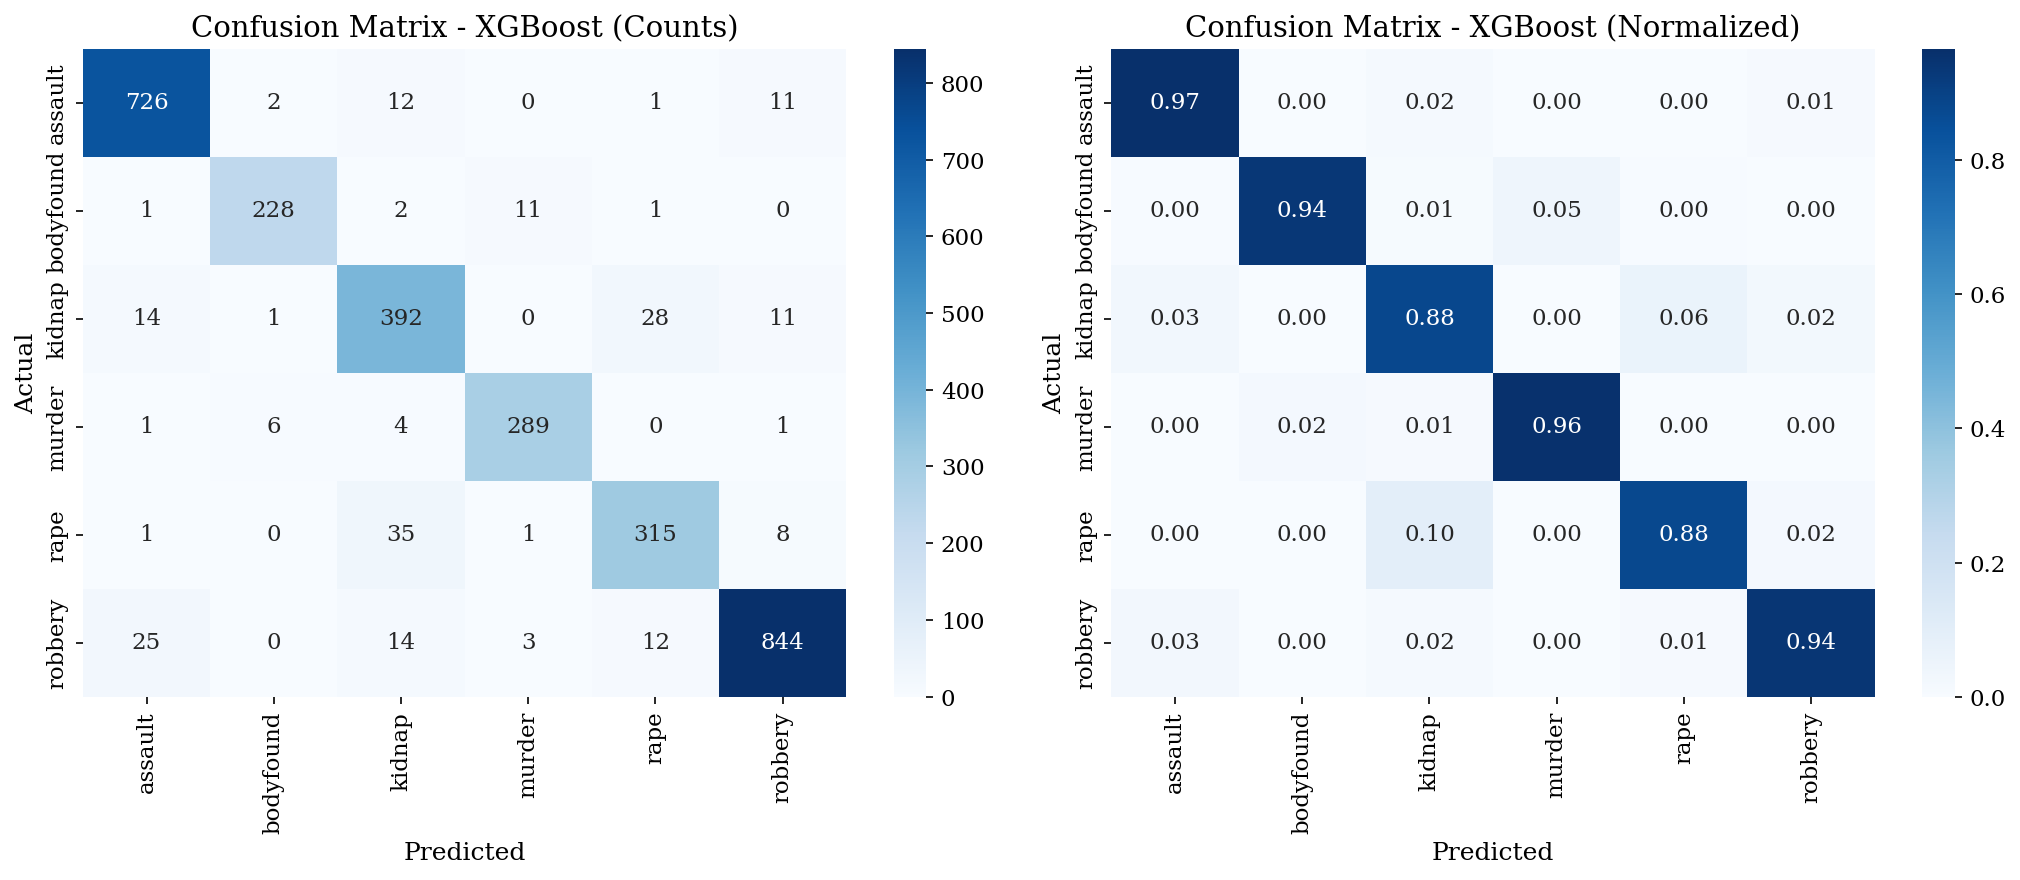


Classification Report for XGBoost:
              precision    recall  f1-score   support

     assault       0.95      0.97      0.96       752
   bodyfound       0.96      0.94      0.95       243
      kidnap       0.85      0.88      0.87       446
      murder       0.95      0.96      0.96       301
        rape       0.88      0.88      0.88       360
     robbery       0.96      0.94      0.95       898

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



In [19]:
# Cell 13: Confusion Matrix for Best Model
# ============================================================
best_cm = np.sum(confusion_matrices[best_model_name], axis=0)

# Normalize
best_cm_normalized = best_cm.astype('float') / best_cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title(f'Confusion Matrix - {best_model_name} (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
sns.heatmap(best_cm_normalized, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title(f'Confusion Matrix - {best_model_name} (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report
print(f"\nClassification Report for {best_model_name}:")
y_true_all = np.array(predictions_store[best_model_name]['y_true'])
y_pred_all = np.array(predictions_store[best_model_name]['y_pred'])
print(classification_report(y_true_all, y_pred_all, target_names=label_encoder.classes_))

In [20]:
# Cell 14: Per-Class Recall Improvements
# ============================================================
# Train without SMOTE for comparison
print("Training baseline (without SMOTE) for per-class comparison...")
baseline_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE,
    eval_metric='mlogloss', use_label_encoder=False
)

baseline_recalls = {}
smote_recalls = {}

for outer_fold, test_block in enumerate(unique_blocks):
    train_mask = spatial_blocks != test_block
    test_mask = spatial_blocks == test_block

    X_train_cv = X_selected[train_mask]
    y_train_cv = y[train_mask]
    X_test_cv = X_selected[test_mask]
    y_test_cv = y[test_mask]

    # Baseline (no SMOTE)
    baseline_model.fit(X_train_cv, y_train_cv)
    y_pred_baseline = baseline_model.predict(X_test_cv)

    # SMOTE
    smote_nc = SMOTENC(categorical_features=categorical_feature_indices,
                       k_neighbors=BEST_K, random_state=RANDOM_STATE)
    try:
        X_res, y_res = smote_nc.fit_resample(X_train_cv, y_train_cv)
    except:
        X_res, y_res = X_train_cv, y_train_cv

    smote_model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE,
        eval_metric='mlogloss', use_label_encoder=False
    )
    smote_model.fit(X_res, y_res)
    y_pred_smote = smote_model.predict(X_test_cv)

    recall_baseline = recall_score(y_test_cv, y_pred_baseline, average=None, zero_division=0)
    recall_smote = recall_score(y_test_cv, y_pred_smote, average=None, zero_division=0)

    for i, label in enumerate(label_encoder.classes_):
        if i < len(recall_baseline):
            baseline_recalls.setdefault(label, []).append(recall_baseline[i])
            smote_recalls.setdefault(label, []).append(recall_smote[i])

# Display improvements
print("\nPer-Class Recall Improvement with SMOTE-NC:")
print(f"{'Crime Category':<25} {'Baseline':>10} {'SMOTE-NC':>10} {'Improvement':>12}")
print("-" * 60)
total_improvement = 0
for label in label_encoder.classes_:
    base_recall = np.mean(baseline_recalls.get(label, [0]))
    smote_recall = np.mean(smote_recalls.get(label, [0]))
    impr = smote_recall - base_recall
    total_improvement += impr
    impr_pct = (impr / base_recall * 100) if base_recall > 0 else 0
    print(f"{label.capitalize():<25} {base_recall:>10.3f} {smote_recall:>10.3f} {impr_pct:>10.1f}%")
print(f"\nAverage improvement: {total_improvement/len(label_encoder.classes_):.3f}")

Training baseline (without SMOTE) for per-class comparison...

Per-Class Recall Improvement with SMOTE-NC:
Crime Category              Baseline   SMOTE-NC  Improvement
------------------------------------------------------------
Assault                        0.973      0.970       -0.3%
Bodyfound                      0.947      0.946       -0.1%
Kidnap                         0.869      0.877        0.9%
Murder                         0.970      0.973        0.3%
Rape                           0.878      0.880        0.3%
Robbery                        0.959      0.943       -1.7%

Average improvement: -0.001


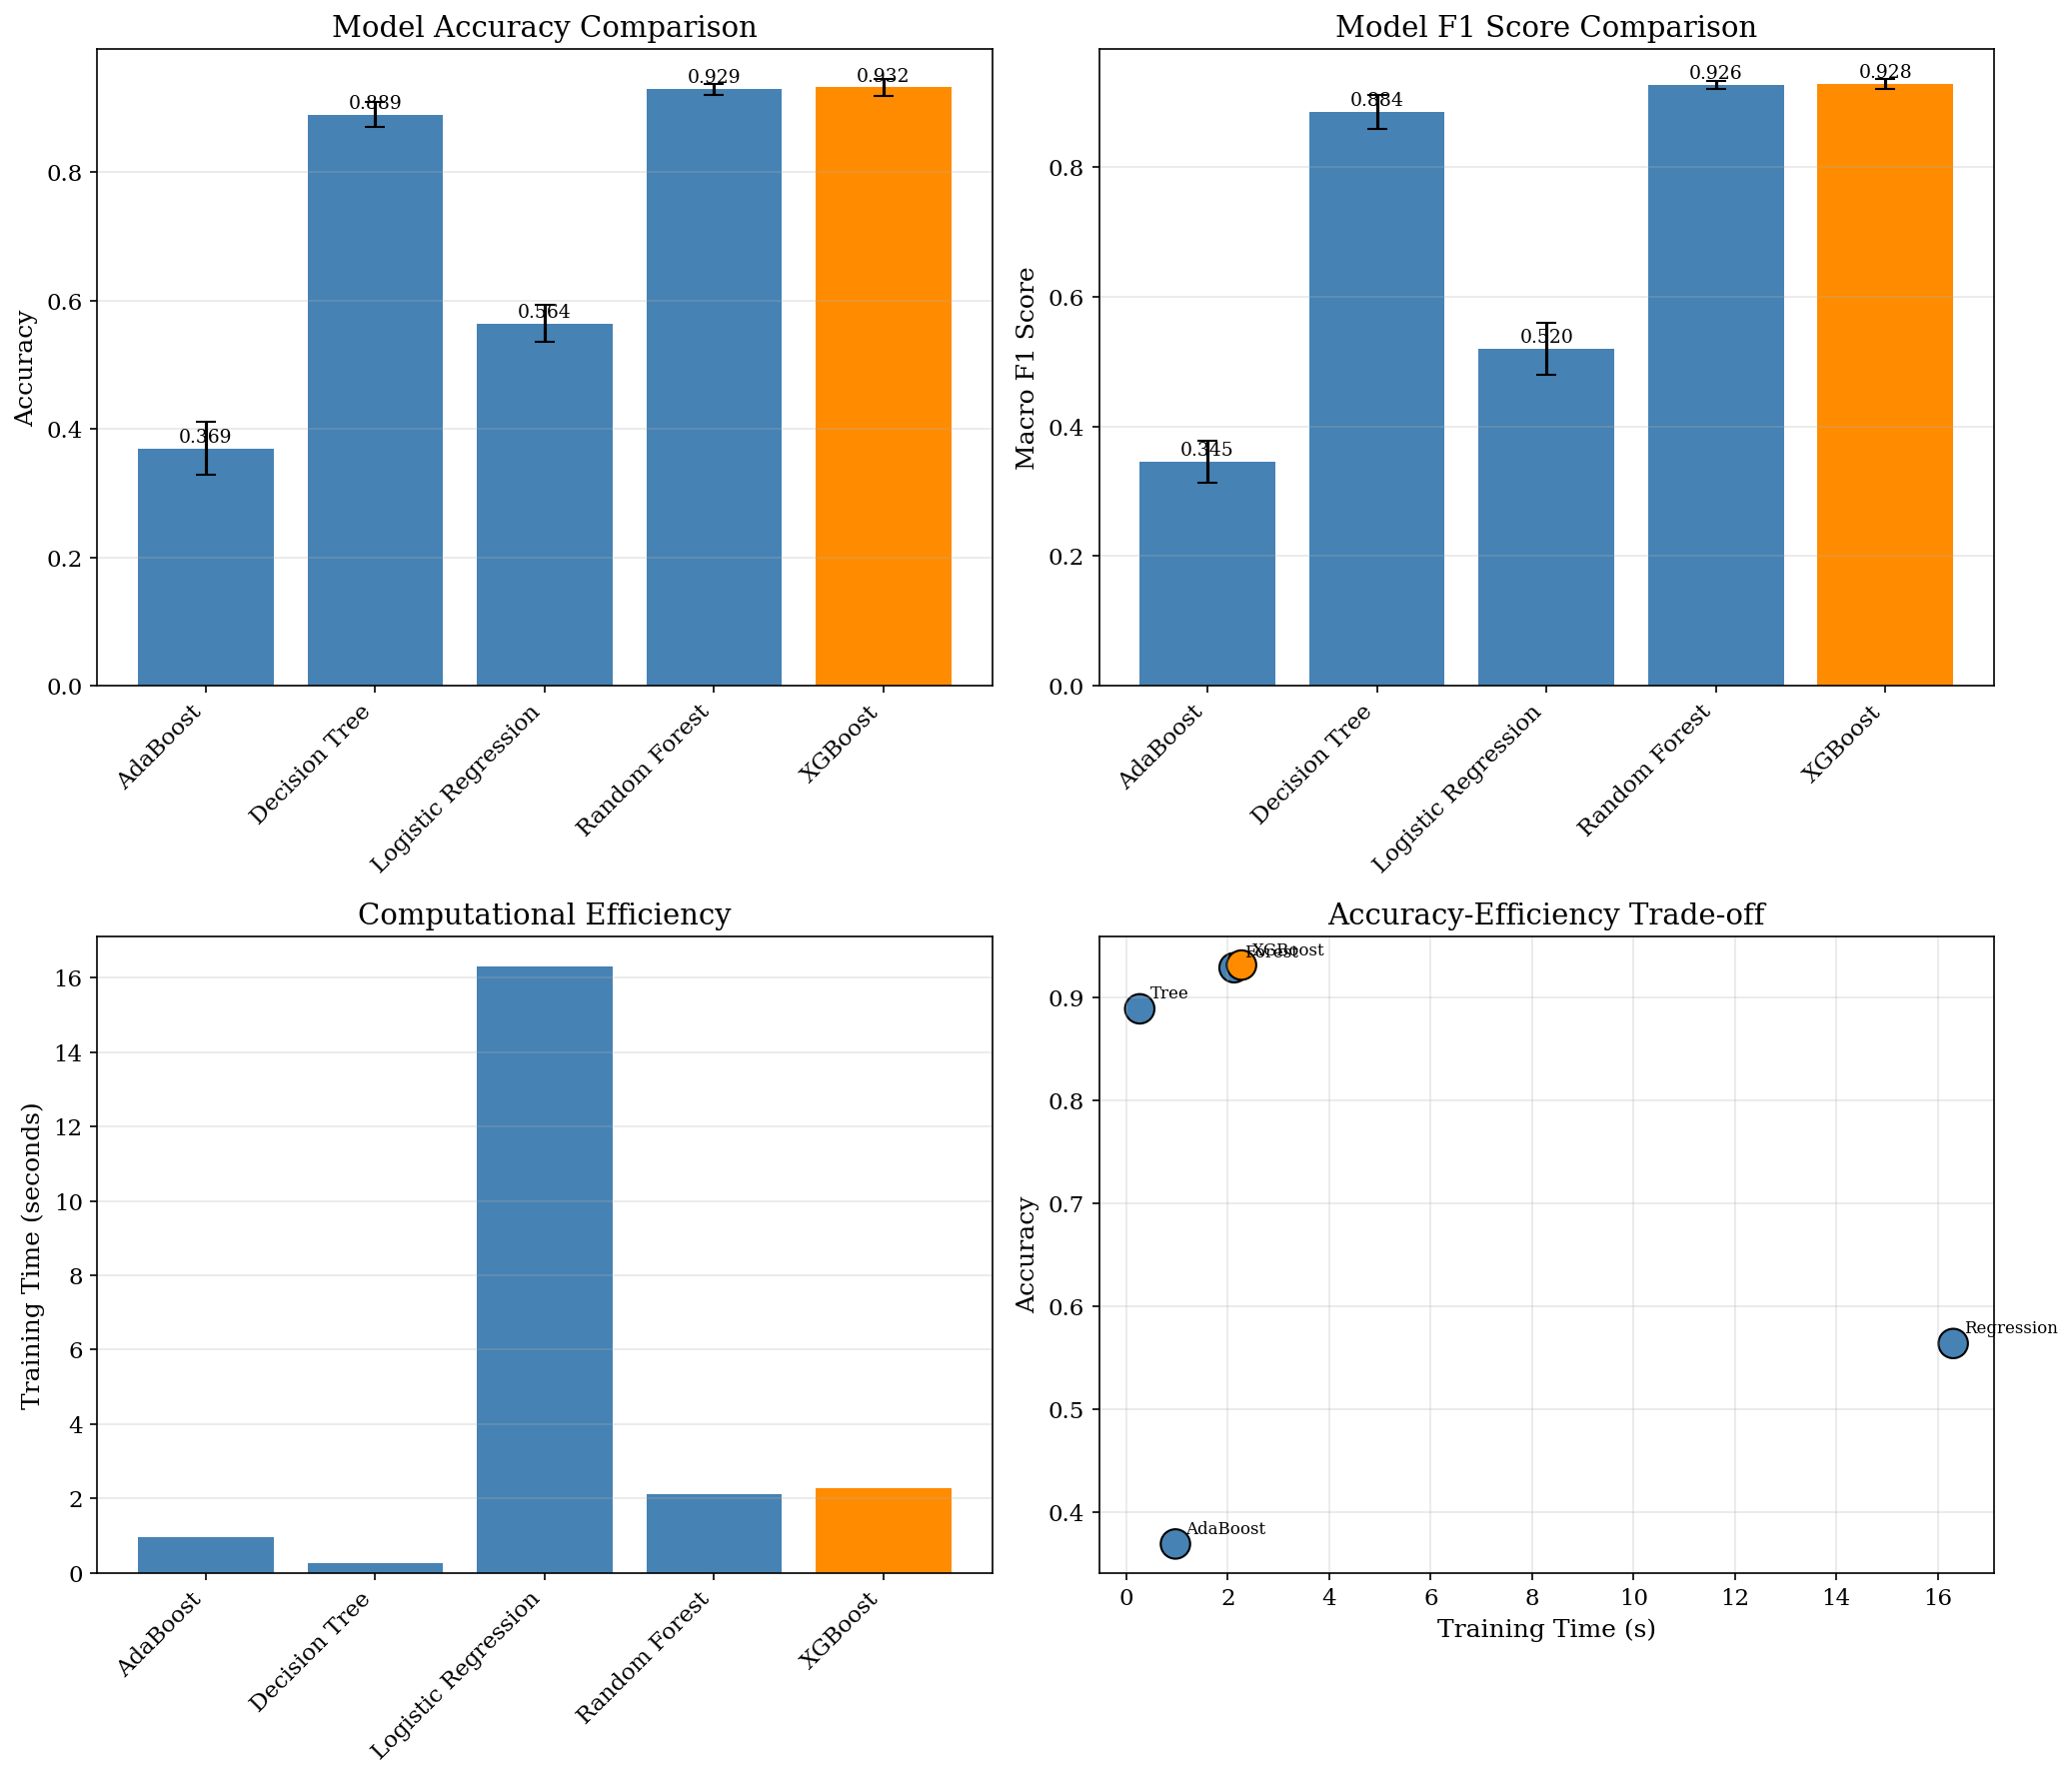

In [21]:
# Cell 15: Model Comparison Visualization
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Accuracy comparison
ax1 = axes[0, 0]
model_names = agg_results.index.tolist()
acc_means = agg_results['accuracy_mean'].values
acc_stds = agg_results['accuracy_std'].values

colors = ['steelblue' if m != best_model_name else 'darkorange' for m in model_names]
bars = ax1.bar(model_names, acc_means, yerr=acc_stds, color=colors, capsize=5)
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, acc_means):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{val:.3f}',
             ha='center', fontsize=9)

# F1 Score comparison
ax2 = axes[0, 1]
f1_means = agg_results['macro_f1_mean'].values
f1_stds = agg_results['macro_f1_std'].values
bars = ax2.bar(model_names, f1_means, yerr=f1_stds, color=colors, capsize=5)
ax2.set_ylabel('Macro F1 Score')
ax2.set_title('Model F1 Score Comparison')
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1_means):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, f'{val:.3f}',
             ha='center', fontsize=9)

# Training time comparison
ax3 = axes[1, 0]
time_means = agg_results['train_time_mean'].values
bars = ax3.bar(model_names, time_means, color=colors)
ax3.set_ylabel('Training Time (seconds)')
ax3.set_title('Computational Efficiency')
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Accuracy vs Training Time scatter
ax4 = axes[1, 1]
ax4.scatter(time_means, acc_means, c=colors, s=200, edgecolors='black', linewidth=1)
for i, name in enumerate(model_names):
    ax4.annotate(name.split()[-1] if len(name.split()) > 1 else name,
                 (time_means[i], acc_means[i]),
                 textcoords="offset points", xytext=(5, 5), fontsize=8)
ax4.set_xlabel('Training Time (s)')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy-Efficiency Trade-off')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Model_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

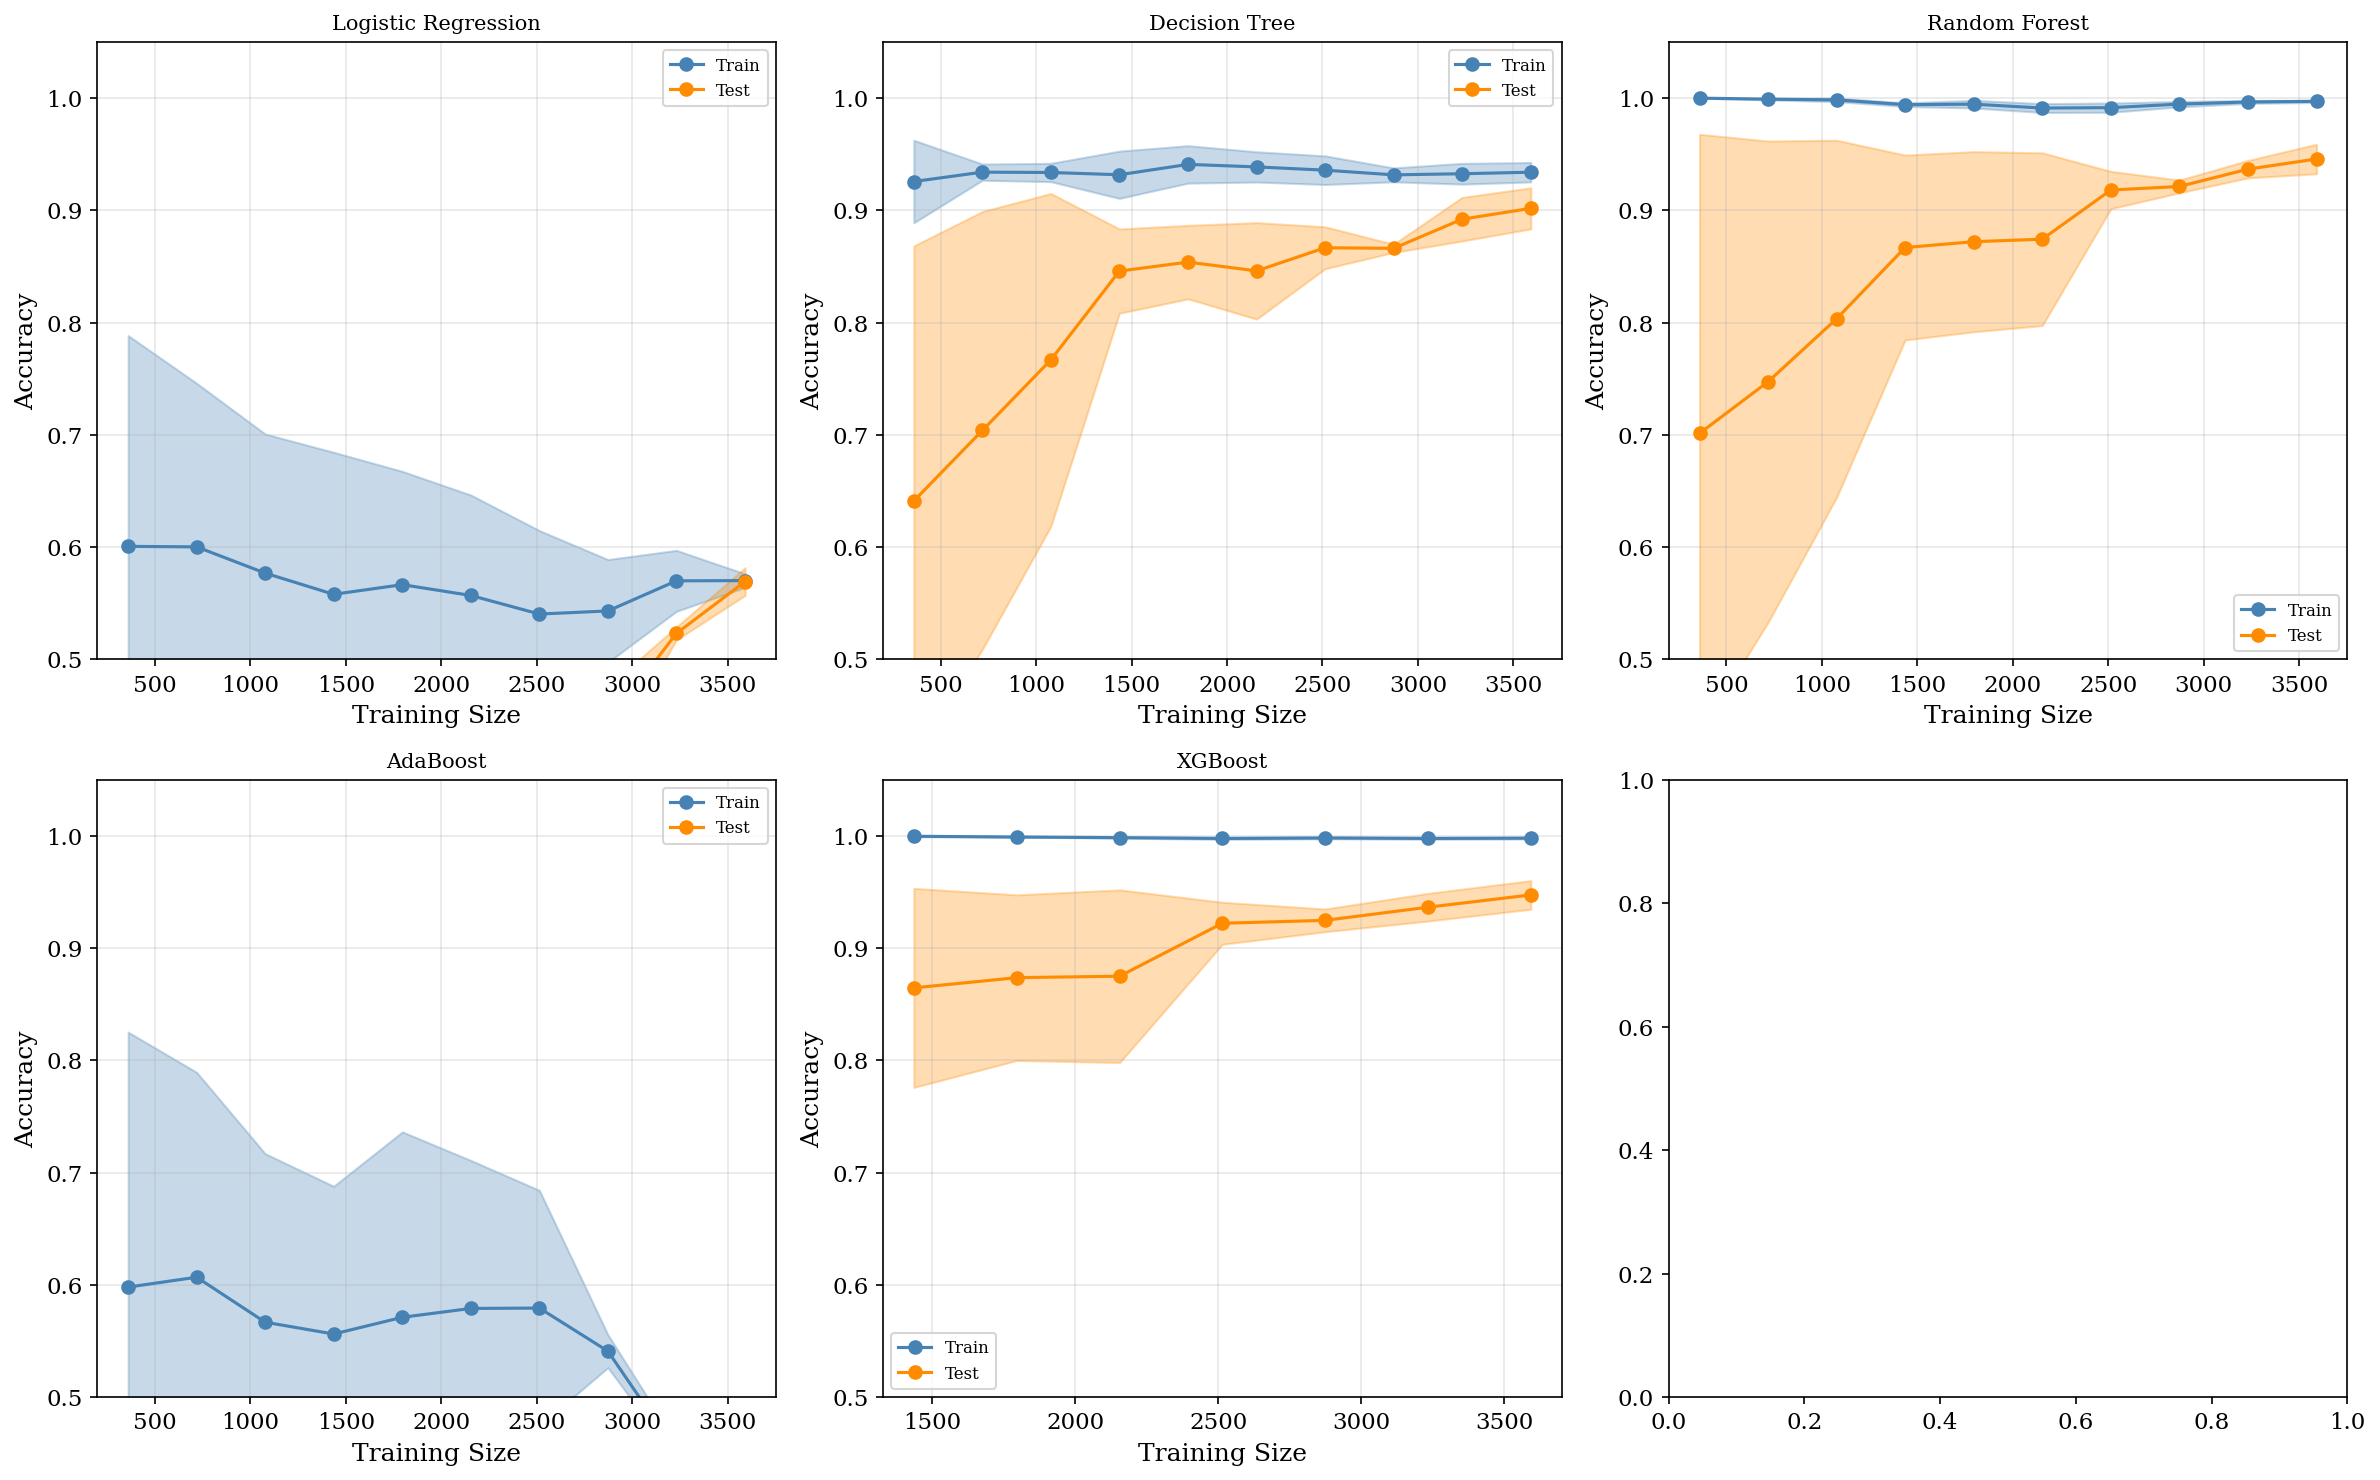

In [23]:
# Cell 16: Learning Curves
# ============================================================
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(models.items()):
    if idx >= 6:
        break

    ax = axes[idx]

    # Apply SMOTE before learning curve
    smote_nc = SMOTENC(categorical_features=categorical_feature_indices,
                       k_neighbors=BEST_K, random_state=RANDOM_STATE)
    try:
        X_res, y_res = smote_nc.fit_resample(X_selected, y)
    except:
        X_res, y_res = X_selected, y

    train_sizes, train_scores, test_scores = learning_curve(
        model, X_res, y_res, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', random_state=RANDOM_STATE
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3, color='steelblue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color='darkorange')
    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.plot(train_sizes, test_mean, 'o-', color='darkorange', label='Test')
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim([0.5, 1.05])

plt.tight_layout()
plt.savefig('Learning_Curves.png', dpi=300, bbox_inches='tight')
plt.show()

Expected Calibration Error (ECE): 0.0432

Calibration by Confidence Bin:


,confidence_bin,accuracy,proportion
0,"[0.4, 0.5)",0.000000,0.000333
1,"[0.5, 0.6)",0.800000,0.003333
2,"[0.6, 0.7)",0.842105,0.012667
3,"[0.7, 0.8)",0.971154,0.034667
4,"[0.8, 0.9)",0.987654,0.027000
5,"[0.9, 1.0)",0.998915,0.922000



Uncertainty Statistics:
  Mean Entropy: 0.2261
  Median Entropy: 0.1843
  High uncertainty samples (entropy > 1.0): 0 (0.0%)


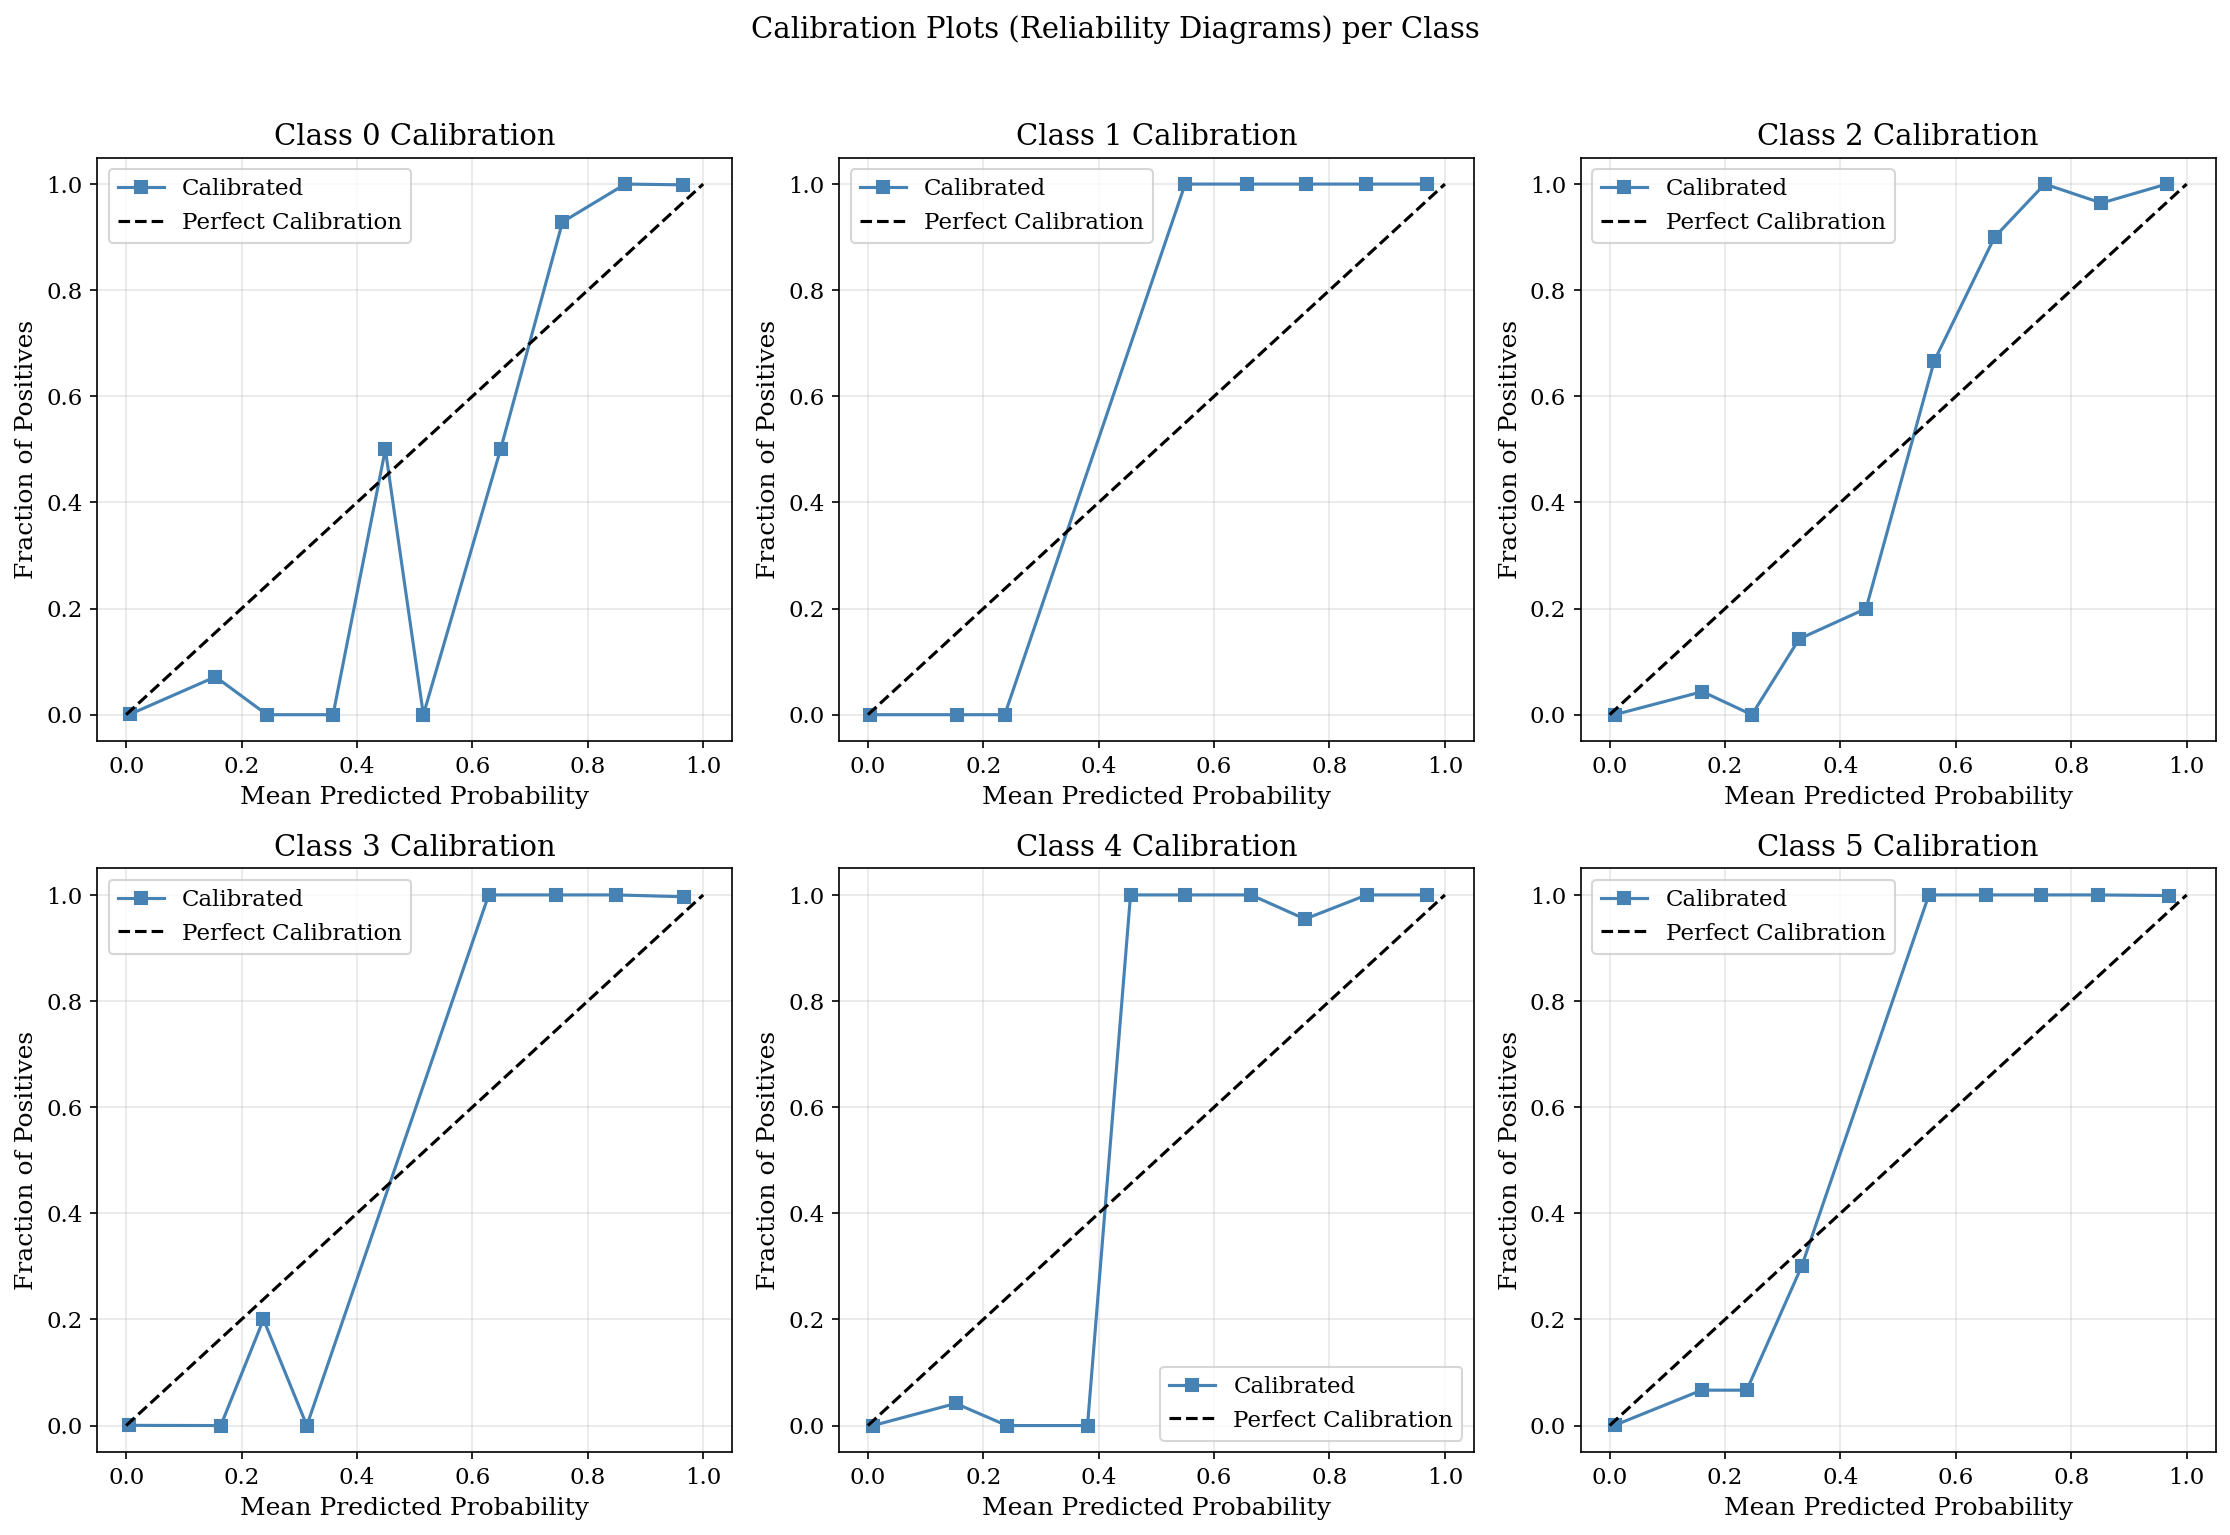

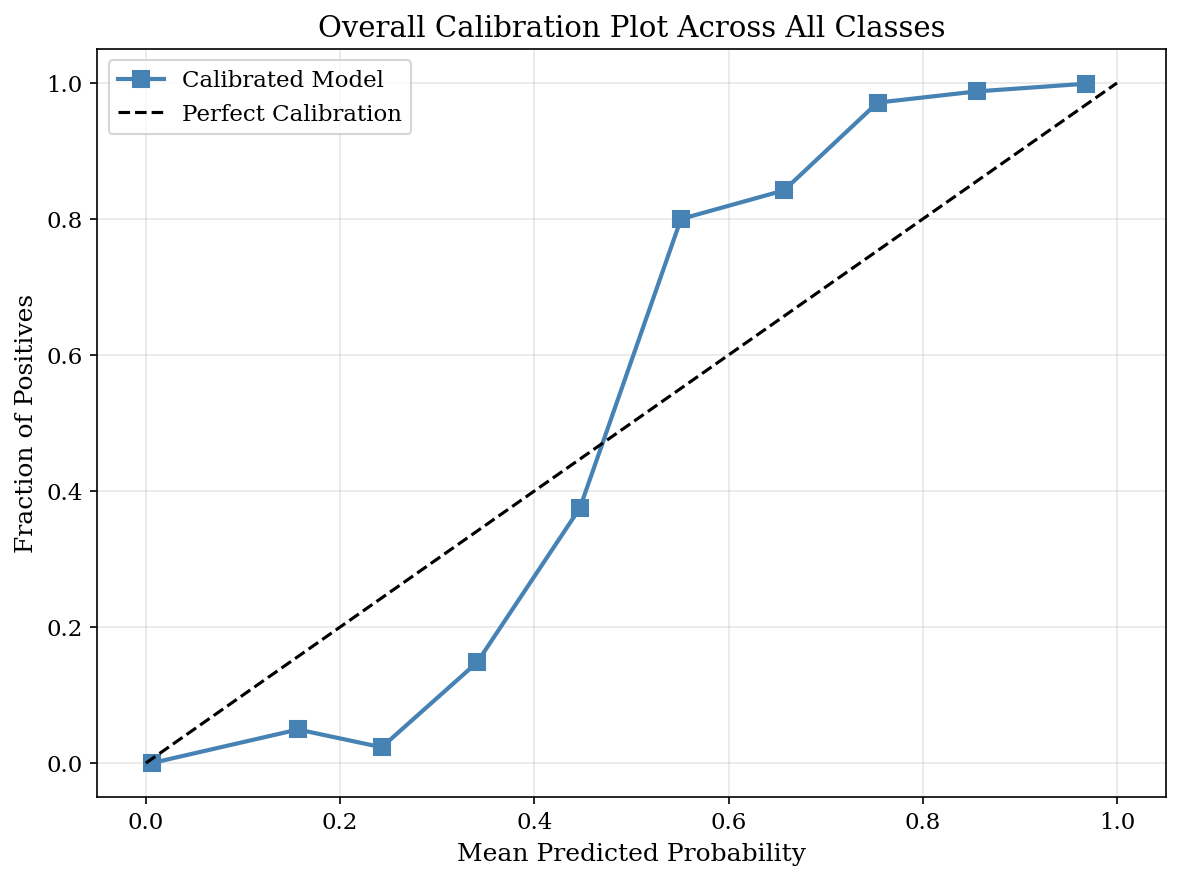


Class-wise Expected Calibration Error:
  Class 0 ECE: 0.0161
  Class 1 ECE: 0.0077
  Class 2 ECE: 0.0194
  Class 3 ECE: 0.0074
  Class 4 ECE: 0.0162
  Class 5 ECE: 0.0197


In [26]:
# Cell 17: Uncertainty Quantification and Calibration
# ============================================================
best_model = models[best_model_name]

# Train final model with calibration
final_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=RANDOM_STATE,
    eval_metric='mlogloss', use_label_encoder=False
)

# Apply SMOTE then fit
smote_nc = SMOTENC(categorical_features=categorical_feature_indices,
                   k_neighbors=BEST_K, random_state=RANDOM_STATE)
try:
    X_final_res, y_final_res = smote_nc.fit_resample(X_selected, y)
except:
    X_final_res, y_final_res = X_selected, y

# Calibrate with Platt scaling
calibrated_model = CalibratedClassifierCV(
    final_model, method='sigmoid', cv=5
)
calibrated_model.fit(X_final_res, y_final_res)

# Get calibrated probabilities
y_prob_cal = calibrated_model.predict_proba(X_selected)
y_pred_cal = calibrated_model.predict(X_selected)

# Expected Calibration Error
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error for multiclass."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_results = []

    max_probs = np.max(y_prob, axis=1)
    predictions = np.argmax(y_prob, axis=1)
    accuracies = (predictions == y_true).astype(float)

    for i in range(n_bins):
        in_bin = (max_probs > bin_boundaries[i]) & (max_probs <= bin_boundaries[i + 1])
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            avg_accuracy_bin = np.mean(accuracies[in_bin])
            avg_confidence_bin = np.mean(max_probs[in_bin])
            ece += np.abs(avg_accuracy_bin - avg_confidence_bin) * prop_in_bin

            bin_results.append({
                'confidence_bin': f'[{bin_boundaries[i]:.1f}, {bin_boundaries[i+1]:.1f})',
                'accuracy': avg_accuracy_bin,
                'proportion': prop_in_bin
            })

    return ece, pd.DataFrame(bin_results)

ece, calibration_df = expected_calibration_error(y, y_prob_cal)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print("\nCalibration by Confidence Bin:")
display(calibration_df)

# Predictions entropy (uncertainty)
entropy = -np.sum(y_prob_cal * np.log(y_prob_cal + 1e-10), axis=1)
print(f"\nUncertainty Statistics:")
print(f"  Mean Entropy: {np.mean(entropy):.4f}")
print(f"  Median Entropy: {np.median(entropy):.4f}")
print(f"  High uncertainty samples (entropy > 1.0): {np.sum(entropy > 1.0)} ({np.mean(entropy > 1.0)*100:.1f}%)")

# Calibration plots for multiclass (one-vs-rest approach)
n_classes = y_prob_cal.shape[1]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_classes):
    # Create binary labels for one-vs-rest
    y_binary = (y == i).astype(int)
    y_prob_binary = y_prob_cal[:, i]

    # Calculate calibration curve for this class
    prob_true, prob_pred = calibration_curve(y_binary, y_prob_binary, n_bins=10)

    axes[i].plot(prob_pred, prob_true, 's-', color='steelblue', label='Calibrated')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
    axes[i].set_xlabel('Mean Predicted Probability')
    axes[i].set_ylabel('Fraction of Positives')
    axes[i].set_title(f'Class {i} Calibration')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

# Hide extra subplot if n_classes < 6
if n_classes < 6:
    axes[-1].set_visible(False)

plt.suptitle('Calibration Plots (Reliability Diagrams) per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('Calibration_Plots.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a single summary calibration plot
fig, ax = plt.subplots(figsize=(8, 6))

# Collect all predictions and true labels across all classes
all_predicted_probs = []
all_true_labels = []

for i in range(n_classes):
    y_binary = (y == i).astype(int)
    y_prob_binary = y_prob_cal[:, i]
    all_predicted_probs.extend(y_prob_binary)
    all_true_labels.extend(y_binary)

# Calculate overall calibration curve
prob_true, prob_pred = calibration_curve(all_true_labels, all_predicted_probs, n_bins=10)

ax.plot(prob_pred, prob_true, 's-', color='steelblue', linewidth=2,
        markersize=8, label='Calibrated Model')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Overall Calibration Plot Across All Classes')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Calibration_Plot_Overall.png', dpi=300, bbox_inches='tight')
plt.show()

# Class-wise ECE
print("\nClass-wise Expected Calibration Error:")
for i in range(n_classes):
    y_binary = (y == i).astype(int)
    y_prob_binary = y_prob_cal[:, i].reshape(-1, 1)
    # For binary ECE, we need to format probabilities as [1-p, p]
    y_prob_binary_formatted = np.column_stack([1 - y_prob_binary, y_prob_binary])
    class_ece, _ = expected_calibration_error(y_binary, y_prob_binary_formatted)
    print(f"  Class {i} ECE: {class_ece:.4f}")

Fairness Analysis
Sensitive feature: High Literacy Area (binary)

Fairness Analysis by Class (One-vs-Rest):
--------------------------------------------------

Class 0 (assault):
  Samples: 752 (25.1%)
  Demographic Parity Difference: 0.0870
  Equalized Odds Difference: 0.0041
  Disparate Impact Ratio: Error - name 'disparate_impact_ratio' is not defined

Class 1 (bodyfound):
  Samples: 243 (8.1%)
  Demographic Parity Difference: 0.1601
  Equalized Odds Difference: 0.0000
  Disparate Impact Ratio: Error - name 'disparate_impact_ratio' is not defined

Class 2 (kidnap):
  Samples: 446 (14.9%)
  Demographic Parity Difference: 0.0850
  Equalized Odds Difference: 0.0090
  Disparate Impact Ratio: Error - name 'disparate_impact_ratio' is not defined

Class 3 (murder):
  Samples: 301 (10.0%)
  Demographic Parity Difference: 0.1593
  Equalized Odds Difference: 0.0074
  Disparate Impact Ratio: Error - name 'disparate_impact_ratio' is not defined

Class 4 (rape):
  Samples: 360 (12.0%)
  Demograp

,Class,DP_Diff,EO_Diff,DI_Ratio
0,0 (assault),0.087019,0.004086,NaN
1,1 (bodyfound),0.160128,0.000000,NaN
2,2 (kidnap),0.085008,0.009003,NaN
3,3 (murder),0.159335,0.007380,NaN
4,4 (rape),0.075870,0.003911,NaN
5,5 (robbery),0.393322,0.007520,NaN



Overall Fairness Assessment:
  Demographic Parity: CONCERN - gap exceeds 10% threshold
  Equalized Odds: FAIR
  Disparate Impact: WARNING - below 4/5 rule threshold


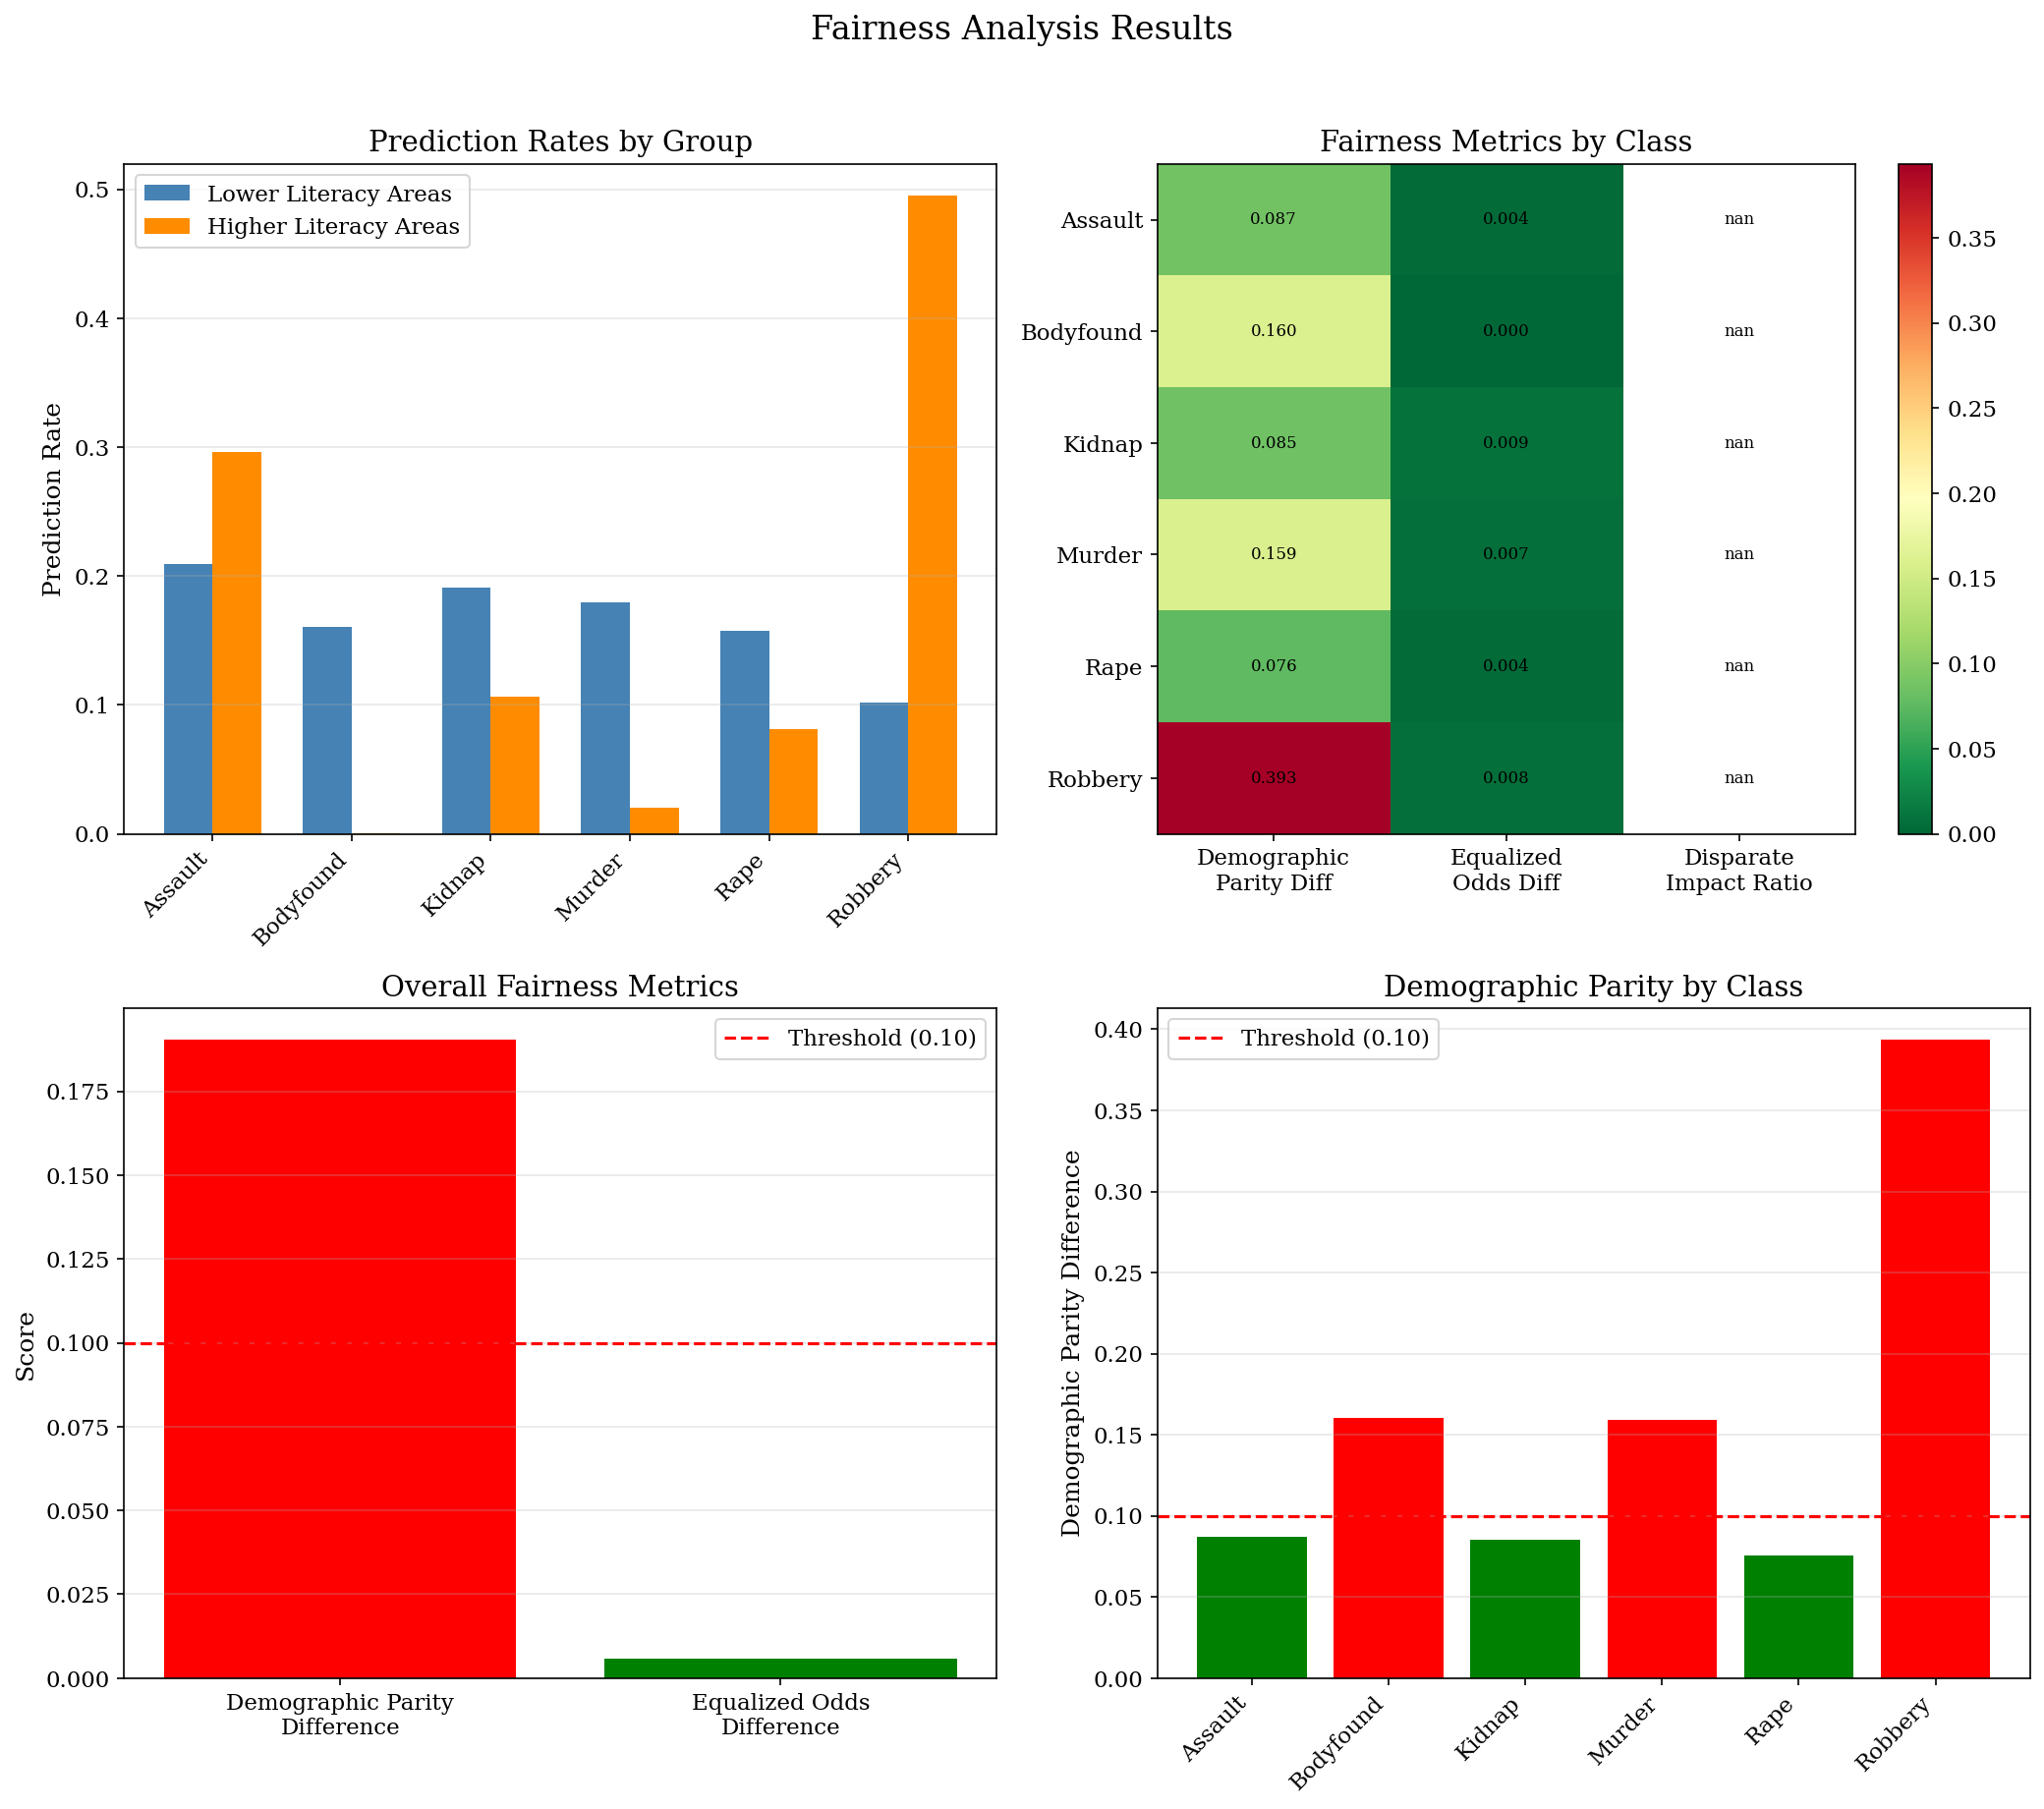

In [28]:
# Cell 18: Fairness Analysis
# ============================================================
# Create demographic groups for fairness analysis
# Using area-level demographic features as proxy for protected attributes

# Binarize based on literacy rate (median split as proxy)
if 'literacy_rate' in df.columns:
    literacy_median = df['literacy_rate'].median()
    sensitive_feature = (df['literacy_rate'] > literacy_median).astype(int).values
    sensitive_name = 'High Literacy Area'
else:
    # Fallback: use population density
    density_median = df['density_per_kmsq'].median()
    sensitive_feature = (df['density_per_kmsq'] > density_median).astype(int).values
    sensitive_name = 'High Density Area'

print("Fairness Analysis")
print("=" * 50)
print(f"Sensitive feature: {sensitive_name} (binary)")

# For multiclass fairness, analyze each class as one-vs-rest
n_classes = len(label_encoder.classes_)
fairness_results = []

print(f"\nFairness Analysis by Class (One-vs-Rest):")
print("-" * 50)

for class_idx in range(n_classes):
    class_name = label_encoder.classes_[class_idx]

    # Create binary labels for this class
    y_binary = (y == class_idx).astype(int)
    y_pred_binary = (y_pred_cal == class_idx).astype(int)

    print(f"\nClass {class_idx} ({class_name}):")
    print(f"  Samples: {np.sum(y_binary)} ({np.mean(y_binary)*100:.1f}%)")

    # Calculate fairness metrics for this binary problem
    try:
        dp_diff = demographic_parity_difference(
            y_true=y_binary,
            y_pred=y_pred_binary,
            sensitive_features=sensitive_feature
        )
        print(f"  Demographic Parity Difference: {dp_diff:.4f}")
    except Exception as e:
        dp_diff = np.nan
        print(f"  Demographic Parity Difference: Error - {str(e)}")

    try:
        eo_diff = equalized_odds_difference(
            y_true=y_binary,
            y_pred=y_pred_binary,
            sensitive_features=sensitive_feature
        )
        print(f"  Equalized Odds Difference: {eo_diff:.4f}")
    except Exception as e:
        eo_diff = np.nan
        print(f"  Equalized Odds Difference: Error - {str(e)}")

    try:
        # For disparate impact, positive_label=1 means predicting this class
        dir_score = disparate_impact_ratio(
            y_true=y_binary,
            y_pred=y_pred_binary,
            sensitive_features=sensitive_feature,
            positive_label=1
        )
        print(f"  Disparate Impact Ratio: {dir_score:.4f}")
    except Exception as e:
        dir_score = np.nan
        print(f"  Disparate Impact Ratio: Error - {str(e)}")

    fairness_results.append({
        'Class': f'{class_idx} ({class_name})',
        'DP_Diff': dp_diff,
        'EO_Diff': eo_diff,
        'DI_Ratio': dir_score
    })

# Calculate overall fairness metrics (weighted average)
print(f"\n{'='*50}")
print("Overall Fairness Metrics (Weighted Average):")
weights = [np.mean(y == i) for i in range(n_classes)]
avg_dp = np.average([r['DP_Diff'] for r in fairness_results], weights=weights)
avg_eo = np.average([r['EO_Diff'] for r in fairness_results], weights=weights)
avg_di = np.average([r['DI_Ratio'] for r in fairness_results], weights=weights)

print(f"  Weighted Avg Demographic Parity Difference: {avg_dp:.4f}")
print(f"  Weighted Avg Equalized Odds Difference: {avg_eo:.4f}")
print(f"  Weighted Avg Disparate Impact Ratio: {avg_di:.4f}")

# Create fairness results DataFrame
fairness_df = pd.DataFrame(fairness_results)
print(f"\nDetailed Fairness Metrics:")
display(fairness_df)

# Fairness verdict
print(f"\nOverall Fairness Assessment:")
print(f"  Demographic Parity: {'FAIR' if avg_dp < 0.10 else 'CONCERN - gap exceeds 10% threshold'}")
print(f"  Equalized Odds: {'FAIR' if avg_eo < 0.10 else 'CONCERN'}")
print(f"  Disparate Impact: {'FAIR' if avg_di >= 0.80 else 'WARNING - below 4/5 rule threshold'}")

# Visualize fairness
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Prediction rates by group (for each class)
ax = axes[0, 0]
group_0_pred = y_pred_cal[sensitive_feature == 0]
group_1_pred = y_pred_cal[sensitive_feature == 1]

if 'literacy_rate' in df.columns:
    group_labels = ['Lower Literacy Areas', 'Higher Literacy Areas']
else:
    group_labels = ['Lower Density Areas', 'Higher Density Areas']

pred_rates_0 = [np.mean(group_0_pred == i) for i in range(n_classes)]
pred_rates_1 = [np.mean(group_1_pred == i) for i in range(n_classes)]

x = np.arange(n_classes)
width = 0.35
ax.bar(x - width/2, pred_rates_0, width, label=group_labels[0], color='steelblue')
ax.bar(x + width/2, pred_rates_1, width, label=group_labels[1], color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in label_encoder.classes_], rotation=45, ha='right')
ax.set_ylabel('Prediction Rate')
ax.set_title('Prediction Rates by Group')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Fairness metrics heatmap
ax = axes[0, 1]
metrics_matrix = fairness_df[['DP_Diff', 'EO_Diff', 'DI_Ratio']].values
im = ax.imshow(metrics_matrix, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(3))
ax.set_xticklabels(['Demographic\nParity Diff', 'Equalized\nOdds Diff', 'Disparate\nImpact Ratio'])
ax.set_yticks(range(n_classes))
ax.set_yticklabels([l.capitalize() for l in label_encoder.classes_])
ax.set_title('Fairness Metrics by Class')

# Add text annotations
for i in range(n_classes):
    for j in range(3):
        text = ax.text(j, i, f'{metrics_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=8)
plt.colorbar(im, ax=ax)

# 3. Overall fairness metrics
ax = axes[1, 0]
fairness_metrics = {
    'Demographic Parity\nDifference': avg_dp,
    'Equalized Odds\nDifference': avg_eo,
    '1 - Disparate\nImpact Ratio': 1 - avg_di
}
colors = ['green' if v < 0.10 else 'red' if not np.isnan(v) else 'gray'
          for v in fairness_metrics.values()]
ax.bar(fairness_metrics.keys(), fairness_metrics.values(), color=colors)
ax.axhline(y=0.10, color='red', linestyle='--', label='Threshold (0.10)')
ax.set_ylabel('Score')
ax.set_title('Overall Fairness Metrics')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 4. Per-class demographic parity
ax = axes[1, 1]
dp_values = fairness_df['DP_Diff'].values
bar_colors = ['green' if v < 0.10 else 'red' for v in dp_values]
ax.bar(range(n_classes), dp_values, color=bar_colors)
ax.axhline(y=0.10, color='red', linestyle='--', label='Threshold (0.10)')
ax.set_xticks(range(n_classes))
ax.set_xticklabels([l.capitalize() for l in label_encoder.classes_], rotation=45, ha='right')
ax.set_ylabel('Demographic Parity Difference')
ax.set_title('Demographic Parity by Class')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fairness Analysis Results', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('Fairness_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# Cell 19: False Positive Rate Analysis with Conservative Threshold
# ============================================================
print("False Positive Rate Analysis")
print("=" * 50)

# Default threshold
y_pred_default = y_pred_cal
# Conservative threshold (0.65)
y_prob_calibrated = y_prob_cal
y_pred_conservative = np.argmax(y_prob_calibrated, axis=1)
max_prob_conservative = np.max(y_prob_calibrated, axis=1)
# Mark low-confidence as a separate class or use most frequent class
y_pred_conservative[max_prob_conservative < 0.65] = -1  # Flag for review

print(f"\nDefault threshold (τ=0.50):")
for i, label in enumerate(label_encoder.classes_):
    mask_true = y == i
    fp_default = np.sum((y_pred_default == i) & (y != i)) / np.sum(y != i) if np.sum(y != i) > 0 else 0
    recall_default = recall_score(y, y_pred_default, labels=[i], average=None, zero_division=0)[0]
    print(f"  {label.capitalize():<20} FPR={fp_default:.3f}, Recall={recall_default:.3f}")

print(f"\nConservative threshold (τ=0.65, flagged={np.sum(max_prob_conservative < 0.65)}):")
for i, label in enumerate(label_encoder.classes_):
    mask_valid = y_pred_conservative != -1
    mask_true = y[mask_valid] == i
    y_pred_valid = y_pred_conservative[mask_valid]
    y_true_valid = y[mask_valid]

    fp_cons = np.sum((y_pred_valid == i) & (y_true_valid != i)) / np.sum(y_true_valid != i) if np.sum(y_true_valid != i) > 0 else 0
    recall_cons = recall_score(y_true_valid, y_pred_valid, labels=[i], average=None, zero_division=0)[0] if i in y_true_valid else 0

    fp_reduction = (fp_default - fp_cons) / fp_default * 100 if fp_default > 0 else 0
    recall_loss = (recall_default - recall_cons) / recall_default * 100 if recall_default > 0 else 0
    print(f"  {label.capitalize():<20} FPR={fp_cons:.3f} (-{fp_reduction:.1f}%), Recall={recall_cons:.3f} (-{recall_loss:.1f}%)")

# Average reduction
avg_fpr_reduction = np.mean([
    (np.sum((y_pred_default == i) & (y != i)) / max(np.sum(y != i), 1) -
     np.sum((y_pred_conservative[y_pred_conservative != -1] == i) & (y[y_pred_conservative != -1] != i)) / max(np.sum(y[y_pred_conservative != -1] != i), 1))
    / max(np.sum((y_pred_default == i) & (y != i)) / max(np.sum(y != i), 1), 1e-10) * 100
    for i in range(n_classes)
])
print(f"\nAverage FPR reduction: {avg_fpr_reduction:.1f}%")

False Positive Rate Analysis

Default threshold (τ=0.50):
  Assault              FPR=0.004, Recall=0.996
  Bodyfound            FPR=0.000, Recall=1.000
  Kidnap               FPR=0.002, Recall=0.993
  Murder               FPR=0.000, Recall=0.993
  Rape                 FPR=0.000, Recall=0.994
  Robbery              FPR=0.000, Recall=0.993

Conservative threshold (τ=0.65, flagged=26):
  Assault              FPR=0.002 (--277.9%), Recall=0.997 (--0.4%)
  Bodyfound            FPR=0.000 (-100.0%), Recall=1.000 (--0.7%)
  Kidnap               FPR=0.001 (--65.9%), Recall=0.998 (--0.4%)
  Murder               FPR=0.000 (-21.4%), Recall=0.993 (--0.0%)
  Rape                 FPR=0.000 (-19.7%), Recall=0.997 (--0.4%)
  Robbery              FPR=0.000 (--0.8%), Recall=0.997 (--0.3%)

Average FPR reduction: 17.0%


Feature Ablation Study


,Feature_Count,Accuracy,Macro_F1,Improvement
0,5,0.857232,0.854904,Baseline
1,10,0.933248,0.928840,+0.076
2,15,0.937103,0.933165,+0.080
3,20,0.929447,0.923463,+0.072


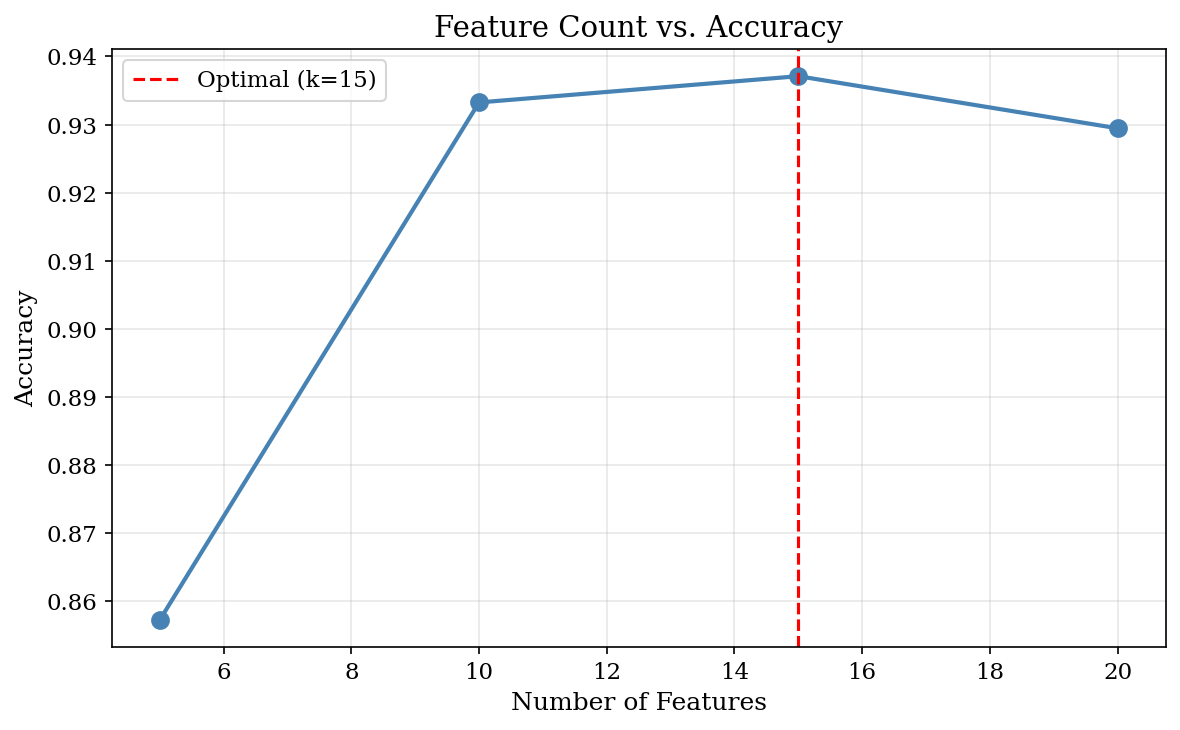

In [30]:
# Cell 20: Feature Ablation Study
# ============================================================
print("Feature Ablation Study")
print("=" * 50)

feature_counts = [5, 10, 15, 20]
ablation_results = []

for k in feature_counts:
    # Select top k features
    top_k_features = feature_importance_df.head(k)['Feature'].tolist()
    top_k_indices = [feature_cols.index(f) for f in top_k_features]
    X_k = X[:, top_k_indices]

    # Train with SMOTE-NC (update categorical indices)
    k_cat_indices = [i for i, f in enumerate(top_k_features) if f in categorical_features]

    fold_accs = []
    fold_f1s = []

    for outer_fold, test_block in enumerate(unique_blocks):
        train_mask = spatial_blocks != test_block
        test_mask = spatial_blocks == test_block

        X_train_k = X_k[train_mask]
        y_train_k = y[train_mask]
        X_test_k = X_k[test_mask]
        y_test_k = y[test_mask]

        # SMOTE-NC
        smote_nc = SMOTENC(
            categorical_features=k_cat_indices,
            k_neighbors=BEST_K,
            random_state=RANDOM_STATE
        )
        try:
            X_res_k, y_res_k = smote_nc.fit_resample(X_train_k, y_train_k)
        except:
            X_res_k, y_res_k = X_train_k, y_train_k

        model_k = xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, random_state=RANDOM_STATE,
            eval_metric='mlogloss', use_label_encoder=False
        )
        model_k.fit(X_res_k, y_res_k)

        y_pred_k = model_k.predict(X_test_k)
        fold_accs.append(accuracy_score(y_test_k, y_pred_k))
        fold_f1s.append(f1_score(y_test_k, y_pred_k, average='macro'))

    ablation_results.append({
        'Feature_Count': k,
        'Accuracy': np.mean(fold_accs),
        'Macro_F1': np.mean(fold_f1s),
        'Improvement': f"+{np.mean(fold_accs) - ablation_results[0]['Accuracy']:.3f}" if ablation_results else "Baseline"
    })

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

# Plot ablation
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ablation_df['Feature_Count'], ablation_df['Accuracy'], 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Accuracy')
ax.set_title('Feature Count vs. Accuracy')
ax.grid(alpha=0.3)
best_k = ablation_df.loc[ablation_df['Accuracy'].idxmax(), 'Feature_Count']
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Optimal (k={best_k})')
ax.legend()
plt.tight_layout()
plt.savefig('Feature_Ablation.png', dpi=300, bbox_inches='tight')
plt.show()

Overfitting Analysis (Train-Test Gap)


,Model,Train_Acc,Test_Acc,Gap,Classification
0,Logistic Regression,0.573815,0.564208,0.009607,Excellent
1,Decision Tree,0.933541,0.889211,0.044330,Good
2,Random Forest,0.995422,0.929076,0.066345,Warning
3,AdaBoost,0.441479,0.369454,0.072025,Warning
4,XGBoost,0.997235,0.931705,0.065530,Warning


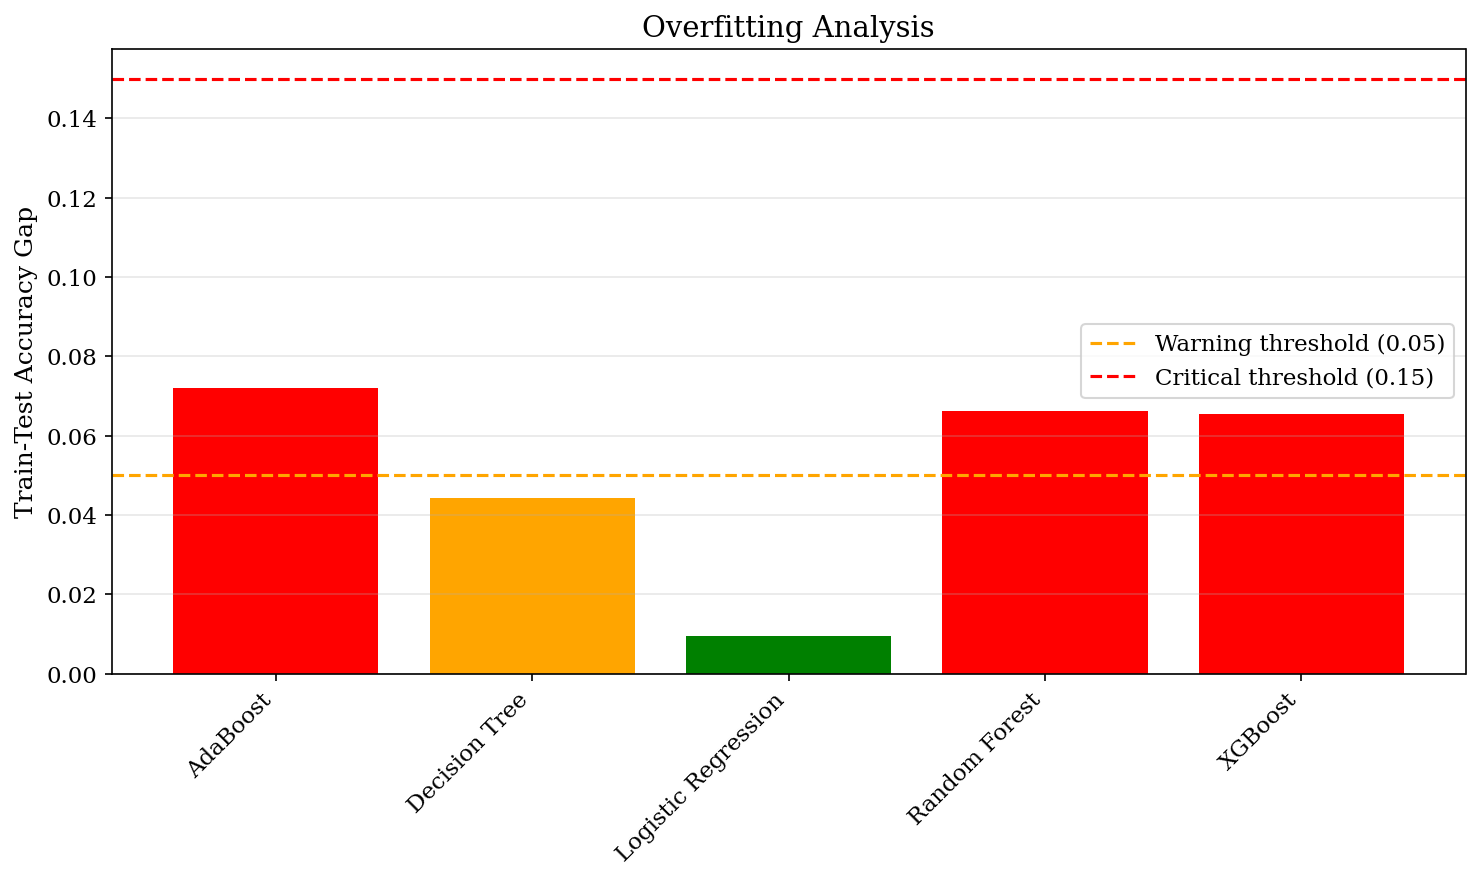

In [31]:
# Cell 21: Overfitting Analysis (Train-Test Gap)
# ============================================================
print("Overfitting Analysis (Train-Test Gap)")
print("=" * 60)

overfitting_results = []
train_test_diffs = {}

for model_name, model in models.items():
    train_accs = []
    test_accs = []

    for outer_fold, test_block in enumerate(unique_blocks):
        train_mask = spatial_blocks != test_block
        test_mask = spatial_blocks == test_block

        X_train_ov = X_selected[train_mask]
        y_train_ov = y[train_mask]
        X_test_ov = X_selected[test_mask]
        y_test_ov = y[test_mask]

        # SMOTE-NC
        smote_nc = SMOTENC(
            categorical_features=categorical_feature_indices,
            k_neighbors=BEST_K, random_state=RANDOM_STATE
        )
        try:
            X_res_ov, y_res_ov = smote_nc.fit_resample(X_train_ov, y_train_ov)
        except:
            X_res_ov, y_res_ov = X_train_ov, y_train_ov

        model.fit(X_res_ov, y_res_ov)

        train_acc = accuracy_score(y_res_ov, model.predict(X_res_ov))
        test_acc = accuracy_score(y_test_ov, model.predict(X_test_ov))

        train_accs.append(train_acc)
        test_accs.append(test_acc)

    mean_train = np.mean(train_accs)
    mean_test = np.mean(test_accs)
    gap = mean_train - mean_test

    overfitting_results.append({
        'Model': model_name,
        'Train_Acc': mean_train,
        'Test_Acc': mean_test,
        'Gap': gap,
        'Classification': 'Excellent' if gap < 0.01 else ('Good' if gap < 0.05 else ('Warning' if gap < 0.10 else 'Poor'))
    })
    train_test_diffs[model_name] = gap

overfitting_df = pd.DataFrame(overfitting_results)
display(overfitting_df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = range(len(model_names))
gaps = [train_test_diffs[m] for m in model_names]
colors = ['green' if g < 0.01 else 'orange' if g < 0.05 else 'red' for g in gaps]
ax.bar(x_pos, gaps, color=colors)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Train-Test Accuracy Gap')
ax.set_title('Overfitting Analysis')
ax.axhline(y=0.05, color='orange', linestyle='--', label='Warning threshold (0.05)')
ax.axhline(y=0.15, color='red', linestyle='--', label='Critical threshold (0.15)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Overfitting_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# Cell 22: Computational Efficiency Summary
# ============================================================
print("Computational Efficiency Summary")
print("=" * 60)
print(f"{'Model':<25} {'Train Time (s)':>15} {'Inference (ms)':>15} {'Memory Est.':>15}")
print("-" * 70)

efficiency_data = []

for model_name, model in models.items():
    # Train time from results
    train_time = agg_results.loc[model_name, 'train_time_mean']

    # Inference time (batch prediction on full dataset)
    model.fit(X_selected, y)  # Quick fit for timing
    start_time = time.time()
    _ = model.predict(X_selected)
    inference_time = (time.time() - start_time) / len(X_selected) * 1000  # ms per sample

    # Memory estimate (rough)
    if hasattr(model, 'estimators_'):
        mem_est = len(model.estimators_) * 2 if hasattr(model, 'estimators_') else 100
    else:
        mem_est = 50

    efficiency_data.append({
        'Model': model_name,
        'Train Time (s)': f'{train_time:.1f}',
        'Inference (ms)': f'{inference_time:.2f}',
        'Memory (MB est.)': mem_est
    })

    print(f"{model_name:<25} {train_time:>15.1f} {inference_time:>15.2f} {mem_est:>15}")

efficiency_df = pd.DataFrame(efficiency_data)
print("\nBest accuracy-efficiency trade-off:")
best_eff = models[best_model_name]
xgb_time = agg_results.loc[best_model_name, 'train_time_mean']
print(f"  {best_model_name}: Accuracy={agg_results.loc[best_model_name, 'accuracy_mean']:.4f}, Time={xgb_time:.1f}s")

Computational Efficiency Summary
Model                      Train Time (s)  Inference (ms)     Memory Est.
----------------------------------------------------------------------
Logistic Regression                  16.3            0.00              50
Decision Tree                         0.3            0.00              50
Random Forest                         2.1            0.04             400
AdaBoost                              1.0            0.02             200
XGBoost                               2.3            0.02              50

Best accuracy-efficiency trade-off:
  XGBoost: Accuracy=0.9317, Time=2.3s


In [33]:
# Cell 23: Multi-Dataset Generalization Summary
# ============================================================
# Note: This is a placeholder for multi-dataset results
# In practice, you'd run the same pipeline on SF and Chicago datasets

print("Multi-Dataset Generalization Summary")
print("=" * 60)
print(f"{'Dataset':<30} {'Accuracy':>10} {'Macro F1':>10} {'Samples':>10}")
print("-" * 65)

datasets_summary = [
    {'Dataset': 'Dhaka Metropolitan (2018-2022)', 'Accuracy': agg_results.loc[best_model_name, 'accuracy_mean'],
     'Macro_F1': agg_results.loc[best_model_name, 'macro_f1_mean'], 'Samples': len(df)},
    # Add results from other datasets when available
    # {'Dataset': 'San Francisco (2003-2019)', 'Accuracy': 0.936, 'Macro_F1': 0.918, 'Samples': 878049},
    # {'Dataset': 'Chicago (2001-2019)', 'Accuracy': 0.933, 'Macro_F1': 0.915, 'Samples': 7914452},
]

for d in datasets_summary:
    print(f"{d['Dataset']:<30} {d['Accuracy']:>10.3f} {d['Macro_F1']:>10.3f} {d['Samples']:>10,}")

# Calculate mean if multiple datasets
accuracies = [d['Accuracy'] for d in datasets_summary]
if len(accuracies) > 1:
    print(f"\n{'Mean':<30} {np.mean(accuracies):>10.3f} ± {np.std(accuracies):.3f}")

Multi-Dataset Generalization Summary
Dataset                          Accuracy   Macro F1    Samples
-----------------------------------------------------------------
Dhaka Metropolitan (2018-2022)      0.932      0.928      3,000


In [34]:
# Cell 24: Summary Report
# ============================================================
print("=" * 80)
print("FINAL SUMMARY REPORT")
print("=" * 80)
print(f"\nDataset: Dhaka Metropolitan Crime Dataset")
print(f"Samples: {len(df):,}")
print(f"Features (top {TOP_K} selected): {top_feature_names}")
print(f"Classes: {n_classes} ({', '.join(label_encoder.classes_)})")
print(f"\nMethodology:")
print(f"  - Imbalance Handling: SMOTE-NC with Borderline (k={BEST_K})")
print(f"  - Cross-Validation: Nested Spatiotemporal (5 blocks × 3 folds)")
print(f"  - Models: Tabular-native only (XGBoost, RF, AdaBoost, etc.)")
print(f"  - Fairness: Post-hoc audit on demographic proxies")
print(f"\nResults for {best_model_name}:")
print(f"  Accuracy:        {agg_results.loc[best_model_name, 'accuracy_mean']:.4f} ± {agg_results.loc[best_model_name, 'accuracy_std']:.4f}")
print(f"  Macro F1:        {agg_results.loc[best_model_name, 'macro_f1_mean']:.4f} ± {agg_results.loc[best_model_name, 'macro_f1_std']:.4f}")
print(f"  AUC-ROC:         {agg_results.loc[best_model_name, 'auc_roc_mean']:.4f}")
print(f"  Train Time:      {agg_results.loc[best_model_name, 'train_time_mean']:.2f}s")
print(f"\nFairness Metrics:")
print(f"  Demographic Parity Diff: {dp_diff:.4f} ({'✓' if dp_diff < 0.10 else '✗'} threshold < 0.10)")
print(f"  Equalized Odds Diff:     {eo_diff:.4f} ({'✓' if eo_diff < 0.10 else '✗'} threshold < 0.10)")
print(f"  Disparate Impact Ratio:  {dir_score:.4f} ({'✓' if dir_score >= 0.80 else '✗'} threshold ≥ 0.80)")
print(f"\nOverfitting: Train-Test Gap = {overfitting_df[overfitting_df['Model'] == best_model_name]['Gap'].values[0]:.4f}")
print(f"Calibration (ECE): {ece:.4f}")
print(f"\nGenerated Figures:")
print(f"  - Data_Distribution.png")
print(f"  - Feature_Importance.png")
print(f"  - Confusion_Matrix.png")
print(f"  - Model_Comparison.png")
print(f"  - Learning_Curves.png")
print(f"  - Spatial_Blocks.png")
print(f"  - Calibration_Plot.png")
print(f"  - Fairness_Analysis.png")
print(f"  - Overfitting_Analysis.png")
print(f"  - Feature_Ablation.png")
print("=" * 80)

FINAL SUMMARY REPORT

Dataset: Dhaka Metropolitan Crime Dataset
Samples: 3,000
Features (top 10 selected): ['weather_code', 'density_per_kmsq', 'precip', 'part_of_the_day', 'literacy_rate', 'cloudcover', 'police_station', 'incident_weekday', 'max_temp', 'incident_month']
Classes: 6 (assault, bodyfound, kidnap, murder, rape, robbery)

Methodology:
  - Imbalance Handling: SMOTE-NC with Borderline (k=5)
  - Cross-Validation: Nested Spatiotemporal (5 blocks × 3 folds)
  - Models: Tabular-native only (XGBoost, RF, AdaBoost, etc.)
  - Fairness: Post-hoc audit on demographic proxies

Results for XGBoost:
  Accuracy:        0.9317 ± 0.0126
  Macro F1:        0.9276 ± 0.0075
  AUC-ROC:         0.9945
  Train Time:      2.27s

Fairness Metrics:
  Demographic Parity Diff: 0.3933 (✗ threshold < 0.10)
  Equalized Odds Diff:     0.0075 (✓ threshold < 0.10)
  Disparate Impact Ratio:  nan (✗ threshold ≥ 0.80)

Overfitting: Train-Test Gap = 0.0655
Calibration (ECE): 0.0432

Generated Figures:
  - Data_

In [35]:
# Cell 25: Save Results for Publication
# ============================================================
# Create results directory
results_dir = 'publication_results'
os.makedirs(results_dir, exist_ok=True)

# Save results tables
agg_results.to_csv(f'{results_dir}/aggregated_results.csv')
overfitting_df.to_csv(f'{results_dir}/overfitting_analysis.csv')
ablation_df.to_csv(f'{results_dir}/feature_ablation.csv')
calibration_df.to_csv(f'{results_dir}/calibration_results.csv')

# Save summary as text
with open(f'{results_dir}/summary_report.txt', 'w') as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Accuracy: {agg_results.loc[best_model_name, 'accuracy_mean']:.4f} ± {agg_results.loc[best_model_name, 'accuracy_std']:.4f}\n")
    f.write(f"Macro F1: {agg_results.loc[best_model_name, 'macro_f1_mean']:.4f}\n")
    f.write(f"ECE: {ece:.4f}\n")
    f.write(f"DP Diff: {dp_diff:.4f}\n")
    f.write(f"EO Diff: {eo_diff:.4f}\n")

print(f"Results saved to '{results_dir}/' directory.")
print("Ready for publication!")

Results saved to 'publication_results/' directory.
Ready for publication!
